In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os

# Define the expected folder and file
target_folder = 'ML-Project-data'
search_dir = '/content/drive/'
found_folder = None

print(f"Searching for folder '{target_folder}' in '{search_dir}'...")

# 1. Check specific common paths first (optimization)
possible_paths = [
    os.path.join(search_dir, target_folder),
    os.path.join(search_dir, 'Colab Notebooks', target_folder)
]

for path in possible_paths:
    if os.path.exists(path):
        found_folder = path
        print(f"Found folder at: {found_folder}")
        break

# 2. If not found, do a full recursive walk
if not found_folder:
    for root, dirs, files in os.walk(search_dir):
        if target_folder in dirs:
            found_folder = os.path.join(root, target_folder)
            print(f"Found folder at: {found_folder}")
            break

if found_folder:
    # Construct the file path
    file_path = os.path.join(found_folder, 'Data1', 'comprehensive_dataset.parquet')

    if os.path.exists(file_path):
        print(f"File found at: {file_path}")
        df = pd.read_parquet(file_path)
        display(df.head())
    else:
        print(f"Folder found, but file not at expected path: {file_path}")
        print("Contents of the found folder:")
        # List recursively to help debug
        for root, dirs, files in os.walk(found_folder):
             for name in files:
                 print(os.path.join(root, name))
else:
    print(f"Still could not find '{target_folder}'.")
    print("Note: It might take a moment for Google Drive to sync the shortcut to Colab. You might need to wait a few seconds and try again, or restart the runtime.")

Searching for folder 'ML-Project-data' in '/content/drive/'...
Found folder at: /content/drive/MyDrive/ML-Project-data
File found at: /content/drive/MyDrive/ML-Project-data/Data1/comprehensive_dataset.parquet


,cusip,date,volume_monthly,dollar_volume_monthly,avg_spread_monthly,ytm,price_eom,ret_eom,rating_num,lagged_spread,...,INFLATION_BREAKEVEN,YIELD_CURVE_SLOPE,MOVE_INDEX,is_public,is_traded,is_rated,missing_coupon,missing_time_to_maturity,missing_ytm,missing_avg_spread_monthly
0,000361AQ8,2015-01-31,6685000.0,7.243512e+06,0.002290,4.539705,108.355581,0.010724,13.0,NaN,...,1.65,1.21,86.599998,True,True,False,1,1,0,0
1,000361AQ8,2015-02-28,4635000.0,5.058569e+06,0.001648,4.016557,108.881111,0.009954,13.0,0.002290,...,1.83,1.37,91.400002,True,True,False,1,1,0,0
2,000361AQ8,2015-03-31,170754000.0,1.932933e+08,0.002456,1.737559,113.562519,0.048263,13.0,0.001648,...,1.76,1.38,86.099998,True,True,False,1,1,0,0
3,000361AQ8,2015-04-30,29185000.0,3.327618e+07,0.000175,1.112314,114.030000,0.009243,11.0,0.002456,...,1.94,1.47,75.300003,True,True,False,1,1,0,0
4,00037BAA0,2015-01-31,6020000.0,6.077401e+06,0.001551,1.201243,101.309500,0.007106,6.0,NaN,...,1.65,1.21,86.599998,False,True,False,1,1,0,0


In [ ]:
df.describe()

,date,volume_monthly,dollar_volume_monthly,avg_spread_monthly,ytm,price_eom,ret_eom,rating_num,lagged_spread,spread_volatility_3m,...,HY_OAS,DGS10_macro_final,DGS2_macro_final,INFLATION_BREAKEVEN,YIELD_CURVE_SLOPE,MOVE_INDEX,missing_coupon,missing_time_to_maturity,missing_ytm,missing_avg_spread_monthly
count,2347177,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06,1.123034e+06,1.104069e+06,1.059991e+06,...,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06,2.347177e+06
mean,2020-03-30 01:52:53.698277120,1.888996e+07,1.885576e+07,3.396375e-03,4.326006e+00,9.865264e+01,4.604376e-03,7.866887e+00,3.770233e-03,1.883056e-03,...,4.391665e+00,2.413892e+00,2.005938e+00,2.015272e+00,4.079543e-01,8.006631e+01,2.908707e-01,2.901311e-01,5.545841e-01,2.414931e-01
min,2015-01-31 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,1.711038e-05,1.000000e-06,-9.904967e-01,1.000000e+00,0.000000e+00,0.000000e+00,...,3.040000e+00,5.500000e-01,1.100000e-01,8.700000e-01,-1.060000e+00,3.921000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2018-02-28 00:00:00,0.000000e+00,0.000000e+00,1.219158e-03,3.773107e+00,9.500568e+01,0.000000e+00,6.000000e+00,1.164349e-03,3.927543e-04,...,3.610000e+00,1.600000e+00,6.400000e-01,1.730000e+00,0.000000e+00,5.657000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2020-06-30 00:00:00,3.066400e+04,1.437882e+04,2.344309e-03,3.773107e+00,9.996608e+01,0.000000e+00,8.000000e+00,2.458959e-03,9.229002e-04,...,4.030000e+00,2.310000e+00,1.580000e+00,2.050000e+00,4.400000e-01,7.252000e+01,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
75%,2022-06-30 00:00:00,9.811000e+06,9.976880e+06,3.683570e-03,3.773107e+00,1.072650e+02,4.960520e-03,9.000000e+00,4.634129e-03,2.089136e-03,...,4.830000e+00,3.050000e+00,2.890000e+00,2.330000e+00,9.700000e-01,1.072800e+02,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
max,2024-08-31 00:00:00,1.633021e+10,1.965631e+10,1.765094e+00,6.007496e+04,5.156405e+03,1.541496e+02,2.200000e+01,1.765094e+00,1.248110e+00,...,8.770000e+00,4.880000e+00,5.070000e+00,2.880000e+00,1.710000e+00,1.479200e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,NaN,6.632542e+07,6.635240e+07,7.446124e-03,8.255846e+01,9.629062e+01,1.421387e-01,2.711691e+00,7.356702e-03,5.505927e-03,...,1.115437e+00,1.068632e+00,1.613328e+00,3.914163e-01,6.794424e-01,2.873196e+01,4.541641e-01,4.538228e-01,4.970118e-01,4.279886e-01


In [ ]:
print(f"\n📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date Range: {df['date'].min()} to {df['date'].max()}")

# ============================================
# DISPLAY ALL COLUMNS WITH DETAILS
# ============================================

print("\n" + "="*80)
print("ALL COLUMNS WITH DETAILS")
print("="*80)

# Get column info
column_info = []
for col in df.columns:
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    pct_complete = (non_null / len(df)) * 100
    unique_vals = df[col].nunique()

    column_info.append({
        'Column': col,
        'Type': str(dtype),
        'Non-Null': f"{non_null:,}",
        'Complete%': f"{pct_complete:.1f}%",
        'Unique': f"{unique_vals:,}"
    })

# Create DataFrame for better display
col_df = pd.DataFrame(column_info)

print(f"\n{col_df.to_string(index=False)}")

# ============================================
# CATEGORIZED COLUMN LIST
# ============================================

print("\n" + "="*80)
print("COLUMNS BY CATEGORY")
print("="*80)

# Identify columns
all_cols = df.columns.tolist()

# Identifiers
identifier_cols = [c for c in all_cols if any(x in c.lower() for x in ['cusip', 'gvkey', 'sic'])]
date_cols = [c for c in all_cols if 'date' in c.lower()]

# Bond characteristics
bond_char_cols = [c for c in all_cols if c in ['maturity', 'coupon', 'offering_amt',
                  'offering_date', 'time_to_maturity', 'bond_age', 'amount_outstanding',
                  'security_level']]

# Returns and prices
return_cols = [c for c in all_cols if 'return' in c.lower() or c == 'ret_eom']
price_cols = [c for c in all_cols if 'price' in c.lower() and c not in return_cols]

# Credit ratings
rating_cols = [c for c in all_cols if 'rating' in c.lower() or c == 'ig_indicator']

# Fundamentals
fundamental_cols = [c for c in all_cols if c in ['total_debt', 'leverage', 'debt_to_assets',
                    'roa', 'log_total_assets', 'log_total_debt', 'interest_coverage',
                    'ebitda', 'revt', 'at', 'ebit', 'profit_growth_yoy', 'dlc', 'dltt', 'xint']]

# Macro variables
macro_cols = [c for c in all_cols if any(x in c for x in ['DGS', 'TERM', 'INFLATION',
              'GDP', 'UNEMPLOYMENT', 'CPI', 'CREDIT_SPREAD', 'M2', 'BREAKEVEN', 'SLOPE', 'MOVE'])]

# Market/ETF variables
market_cols = [c for c in all_cols if any(x in c for x in ['SPY', 'LQD', 'HYG', 'AGG',
               'TLT', 'QQQ', 'DIA', 'IWM', 'XL', 'VIX', 'OAS', 'BBB', 'AAA'])]

# Bond-specific trading
trading_cols = [c for c in all_cols if any(x in c.lower() for x in ['volume', 'spread', 'ytm'])]

# Other columns
used_cols = set(identifier_cols + date_cols + bond_char_cols + return_cols + price_cols +
               rating_cols + fundamental_cols + macro_cols + market_cols + trading_cols)
other_cols = [c for c in all_cols if c not in used_cols]

# Print categorized
categories = {
    '🔑 Identifiers': identifier_cols + date_cols,
    '📋 Bond Characteristics': bond_char_cols,
    '📈 Returns': return_cols,
    '💵 Prices': price_cols,
    '⭐ Credit Ratings': rating_cols,
    '💰 Fundamentals': fundamental_cols,
    '🌍 Macro Variables': macro_cols,
    '📊 Market/ETF Variables': market_cols,
    '💹 Trading Metrics': trading_cols,
    '📦 Other': other_cols
}

for category, cols in categories.items():
    if cols:
        print(f"\n{category} ({len(cols)} columns):")
        for i, col in enumerate(cols, 1):
            pct = (df[col].notna().sum() / len(df)) * 100
            print(f"   {i:2d}. {col:35s} ({pct:5.1f}% complete)")

# ============================================
# SIMPLE LIST (EASY TO COPY)
# ============================================

print("\n" + "="*80)
print("SIMPLE COLUMN LIST (Copy-Paste Friendly)")
print("="*80)

print("\n# All columns:")
for i, col in enumerate(all_cols, 1):
    print(f"{i:3d}. {col}")


📊 Dataset Shape: 2,347,177 rows × 132 columns
   Date Range: 2015-01-31 00:00:00 to 2024-08-31 00:00:00

ALL COLUMNS WITH DETAILS

                    Column           Type  Non-Null Complete%    Unique
                     cusip         object 2,347,177    100.0%    78,421
                      date datetime64[ns] 2,347,177    100.0%       116
            volume_monthly        float64 2,347,177    100.0%   298,758
     dollar_volume_monthly        float64 2,347,177    100.0% 1,218,848
        avg_spread_monthly        float64 2,347,177    100.0% 1,015,466
                       ytm        float64 2,347,177    100.0%   949,810
                 price_eom        float64 2,347,177    100.0%   826,871
                   ret_eom        float64 2,347,177    100.0% 1,338,838
                rating_num        float64 1,123,034     47.8%        22
             lagged_spread        float64 1,104,069     47.0%   992,493
      spread_volatility_3m        float64 1,059,991     45.2% 1,001,378
    

In [ ]:
"""
ADVANCED FEATURE ENGINEERING FOR BOND YIELD/RETURN PREDICTION
Based on Gu et al. (2020) and Fixed Income Best Practices
"""

import pandas as pd
import numpy as np
from scipy import stats

print("="*80)
print("ADVANCED FEATURE ENGINEERING")
print("="*80)

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['cusip', 'date']).reset_index(drop=True)

print(f"\n📅 Date range: {df['date'].min()} to {df['date'].max()}")
print(f"🔑 Unique bonds: {df['cusip'].nunique():,}")

# ============================================
# CATEGORY 1: MOMENTUM & TREND FEATURES
# ============================================

print("\n" + "="*80)
print("1️⃣ CREATING MOMENTUM & TREND FEATURES")
print("="*80)

# Price momentum features
print("\n   📈 Price momentum features...")
for window in [1, 3, 6, 12]:
    col_name = f'return_{window}m'
    df[col_name] = df.groupby('cusip')['ret_eom'].transform(
        lambda x: x.rolling(window, min_periods=1).sum()
    )
    print(f"      ✅ {col_name}")

# Return reversals
print("\n   🔄 Return reversal features...")
df['return_reversal_1m'] = -df.groupby('cusip')['ret_eom'].shift(1)
df['return_reversal_3m'] = -df.groupby('cusip')['ret_eom'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
print(f"      ✅ return_reversal_1m, return_reversal_3m")

# Price trends
print("\n   📊 Price trend features...")
for window in [3, 6, 12]:
    col_name = f'price_trend_{window}m'
    df[col_name] = df.groupby('cusip')['price_eom'].transform(
        lambda x: (x / x.shift(window) - 1) if window > 0 else 0
    )
    print(f"      ✅ {col_name}")

# Moving averages
print("\n   📉 Moving average features...")
for window in [3, 6, 12]:
    # Price MA
    ma_col = f'price_ma_{window}m'
    df[ma_col] = df.groupby('cusip')['price_eom'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

    # Price relative to MA
    rel_col = f'price_to_ma_{window}m'
    df[rel_col] = df['price_eom'] / df[ma_col]

    print(f"      ✅ {ma_col}, {rel_col}")

# ============================================
# CATEGORY 2: VOLATILITY FEATURES
# ============================================

print("\n" + "="*80)
print("2️⃣ CREATING VOLATILITY FEATURES")
print("="*80)

# Return volatility
print("\n   📊 Return volatility...")
for window in [3, 6, 12]:
    col_name = f'return_vol_{window}m'
    df[col_name] = df.groupby('cusip')['ret_eom'].transform(
        lambda x: x.rolling(window, min_periods=2).std()
    )
    print(f"      ✅ {col_name}")

# Price volatility
print("\n   💹 Price volatility...")
for window in [3, 6, 12]:
    col_name = f'price_vol_{window}m'
    df[col_name] = df.groupby('cusip')['price_eom'].transform(
        lambda x: x.pct_change().rolling(window, min_periods=2).std()
    )
    print(f"      ✅ {col_name}")

# Realized volatility (sum of squared returns)
print("\n   🎲 Realized volatility...")
for window in [3, 6]:
    col_name = f'realized_vol_{window}m'
    df[col_name] = df.groupby('cusip')['ret_eom'].transform(
        lambda x: np.sqrt((x**2).rolling(window, min_periods=1).sum())
    )
    print(f"      ✅ {col_name}")

# ============================================
# CATEGORY 3: CREDIT RISK FEATURES
# ============================================

print("\n" + "="*80)
print("3️⃣ CREATING CREDIT RISK FEATURES")
print("="*80)

# Rating changes
print("\n   ⭐ Rating momentum...")
df['rating_change_1m'] = df.groupby('cusip')['numerical_rating'].diff()
df['rating_change_3m'] = df.groupby('cusip')['numerical_rating'].transform(
    lambda x: x - x.shift(3)
)
df['rating_change_6m'] = df.groupby('cusip')['numerical_rating'].transform(
    lambda x: x - x.shift(6)
)
print(f"      ✅ rating_change_1m, rating_change_3m, rating_change_6m")

# Rating volatility (how often rating changes)
print("\n   📊 Rating stability...")
df['rating_changes_6m'] = df.groupby('cusip')['rating_change_1m'].transform(
    lambda x: (x != 0).rolling(6, min_periods=1).sum()
)
df['rating_stable'] = (df['rating_changes_6m'] == 0).astype(int)
print(f"      ✅ rating_changes_6m, rating_stable")

# Distance from investment grade boundary
print("\n   🎯 Distance from IG boundary...")
df['distance_to_ig'] = df['numerical_rating'] - 10  # 10 is BBB-/Ba1 boundary
df['near_downgrade'] = ((df['ig_indicator'] == 1) & (df['numerical_rating'] >= 9)).astype(int)
df['near_upgrade'] = ((df['ig_indicator'] == 0) & (df['numerical_rating'] <= 11)).astype(int)
print(f"      ✅ distance_to_ig, near_downgrade, near_upgrade")

# ============================================
# CATEGORY 4: LIQUIDITY FEATURES
# ============================================

print("\n" + "="*80)
print("4️⃣ CREATING LIQUIDITY FEATURES")
print("="*80)

# Trading activity changes
print("\n   💹 Trading activity trends...")
df['volume_change_1m'] = df.groupby('cusip')['volume_monthly'].pct_change()
df['volume_change_3m'] = df.groupby('cusip')['volume_monthly'].transform(
    lambda x: x.pct_change(3)
)

df['dollar_volume_change_1m'] = df.groupby('cusip')['dollar_volume_monthly'].pct_change()
print(f"      ✅ volume_change_1m, volume_change_3m, dollar_volume_change_1m")

# Liquidity momentum
print("\n   💧 Liquidity momentum...")
for window in [3, 6]:
    col_name = f'avg_volume_{window}m'
    df[col_name] = df.groupby('cusip')['volume_monthly'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )

    rel_col = f'volume_to_avg_{window}m'
    df[rel_col] = df['volume_monthly'] / (df[col_name] + 1)

    print(f"      ✅ {col_name}, {rel_col}")

# Zero trading days
print("\n   🚫 Trading inactivity...")
df['zero_volume'] = (df['volume_monthly'] == 0).astype(int)
df['zero_volume_3m'] = df.groupby('cusip')['zero_volume'].transform(
    lambda x: x.rolling(3, min_periods=1).sum()
)
print(f"      ✅ zero_volume, zero_volume_3m")

# ============================================
# CATEGORY 5: MACRO INTERACTION FEATURES
# ============================================

print("\n" + "="*80)
print("5️⃣ CREATING MACRO INTERACTION FEATURES")
print("="*80)

# Macro changes
print("\n   🌍 Macro momentum...")
macro_vars = ['DGS10', 'VIX', 'TERM_SPREAD_10_3M', 'BBB_AAA_SPREAD', 'HY_OAS']
for var in macro_vars:
    if var in df.columns:
        df[f'{var}_change_1m'] = df[var].diff()
        df[f'{var}_change_3m'] = df[var] - df[var].shift(3)
        print(f"      ✅ {var}_change_1m, {var}_change_3m")

# Market beta (bond return correlation with market)
print("\n   📊 Market sensitivity (beta)...")
def rolling_beta(bond_returns, market_returns, window=12):
    """Calculate rolling beta"""
    result = pd.Series(index=bond_returns.index, dtype=float)
    for i in range(window, len(bond_returns)):
        y = bond_returns.iloc[i-window:i].values
        x = market_returns.iloc[i-window:i].values

        if len(y) >= 6 and len(x) >= 6:  # Need minimum observations
            cov = np.cov(y, x)[0, 1]
            var = np.var(x)
            if var > 0:
                result.iloc[i] = cov / var
    return result

# Calculate beta to different market indices
for market in ['SPY_return', 'LQD_return', 'HYG_return']:
    if market in df.columns:
        df[f'beta_to_{market.replace("_return", "")}'] = df.groupby('cusip').apply(
            lambda x: rolling_beta(x['ret_eom'], x[market], window=12)
        ).reset_index(level=0, drop=True)
        print(f"      ✅ beta_to_{market.replace('_return', '')}")

# ============================================
# CATEGORY 6: RELATIVE VALUE FEATURES
# ============================================

print("\n" + "="*80)
print("6️⃣ CREATING RELATIVE VALUE FEATURES")
print("="*80)

# Yield spread to benchmarks
print("\n   💵 Yield spreads...")
if 'ytm' in df.columns:
    df['ytm_spread_to_10y'] = df['ytm'] - df['DGS10']
    df['ytm_spread_to_ig'] = df['ytm'] - (df['DGS10'] + df['IG_OAS'])
    df['ytm_spread_to_comparable'] = np.where(
        df['ig_indicator'] == 1,
        df['ytm'] - (df['DGS10'] + df['IG_OAS']),
        df['ytm'] - (df['DGS10'] + df['HY_OAS'])
    )
    print(f"      ✅ ytm_spread_to_10y, ytm_spread_to_ig, ytm_spread_to_comparable")

# Price premium/discount to par
print("\n   💰 Price relative to par...")
df['price_to_par'] = df['price_eom'] / 100
df['discount_bond'] = (df['price_eom'] < 100).astype(int)
df['premium_bond'] = (df['price_eom'] > 100).astype(int)
print(f"      ✅ price_to_par, discount_bond, premium_bond")

# Coupon carry
print("\n   🎫 Coupon effects...")
df['high_coupon'] = (df['coupon'] > df.groupby('date')['coupon'].transform('median')).astype(int)
df['coupon_to_ytm'] = np.where(df['ytm'] != 0, df['coupon'] / df['ytm'], np.nan)
print(f"      ✅ high_coupon, coupon_to_ytm")

# ============================================
# CATEGORY 7: TIME-BASED FEATURES
# ============================================

print("\n" + "="*80)
print("7️⃣ CREATING TIME-BASED FEATURES")
print("="*80)

# Maturity buckets
print("\n   ⏰ Maturity features...")
df['maturity_bucket'] = pd.cut(df['time_to_maturity'],
                                bins=[0, 1, 3, 5, 10, 30, 100],
                                labels=['0-1y', '1-3y', '3-5y', '5-10y', '10-30y', '30y+'])

df['short_maturity'] = (df['time_to_maturity'] < 3).astype(int)
df['medium_maturity'] = ((df['time_to_maturity'] >= 3) & (df['time_to_maturity'] < 10)).astype(int)
df['long_maturity'] = (df['time_to_maturity'] >= 10).astype(int)
print(f"      ✅ maturity_bucket, short/medium/long_maturity")

# Seasoning
print("\n   🕐 Bond seasoning...")
df['newly_issued'] = (df['bond_age'] < 1).astype(int)
df['seasoned'] = (df['bond_age'] > 5).astype(int)
print(f"      ✅ newly_issued, seasoned")

# Calendar effects
print("\n   📅 Calendar features...")
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['year'] = df['date'].dt.year
df['year_month'] = df['year'] * 100 + df['month']

# Month-end effects
df['is_december'] = (df['month'] == 12).astype(int)
df['is_quarter_end'] = df['month'].isin([3, 6, 9, 12]).astype(int)
print(f"      ✅ month, quarter, year, is_december, is_quarter_end")

# ============================================
# CATEGORY 8: CROSS-SECTIONAL RANKING FEATURES
# ============================================

print("\n" + "="*80)
print("8️⃣ CREATING CROSS-SECTIONAL RANKING FEATURES")
print("="*80)

# Rank bonds within each month
print("\n   🏆 Monthly rankings...")

rank_features = {
    'ytm': 'ytm_rank',
    'volume_monthly': 'volume_rank',
    'avg_spread_monthly': 'spread_rank',
    'return_3m': 'momentum_3m_rank',
    'return_vol_3m': 'vol_rank'
}

for source_col, rank_col in rank_features.items():
    if source_col in df.columns:
        df[rank_col] = df.groupby('date')[source_col].rank(pct=True)
        print(f"      ✅ {rank_col}")

# ============================================
# CATEGORY 9: INTERACTION FEATURES
# ============================================

print("\n" + "="*80)
print("9️⃣ CREATING INTERACTION FEATURES")
print("="*80)

print("\n   🔗 Key interactions...")

# Credit quality × Liquidity
df['rating_volume_interaction'] = df['numerical_rating'] * np.log1p(df['volume_monthly'])

# Credit quality × Maturity
df['rating_maturity_interaction'] = df['numerical_rating'] * df['time_to_maturity']

# Volatility × Spread
df['vol_spread_interaction'] = df['return_vol_3m'] * df['avg_spread_monthly']

# Macro stress × Credit quality
df['vix_rating_interaction'] = df['VIX'] * df['numerical_rating']

# Term spread × Maturity
df['term_spread_maturity'] = df['TERM_SPREAD_10_3M'] * df['time_to_maturity']

print(f"      ✅ Created 5 key interaction features")

# ============================================
# CATEGORY 10: LAG FEATURES
# ============================================

print("\n" + "="*80)
print("🔟 CREATING LAG FEATURES")
print("="*80)

print("\n   ⏮️ Lagged features...")

lag_features = ['ytm', 'price_eom', 'volume_monthly', 'avg_spread_monthly',
                'numerical_rating', 'leverage', 'VIX', 'DGS10']

for feature in lag_features:
    if feature in df.columns:
        for lag in [1, 3, 6]:
            if feature in ['numerical_rating', 'leverage']:
                # For bond-specific features, lag within bond
                col_name = f'{feature}_lag{lag}m'
                df[col_name] = df.groupby('cusip')[feature].shift(lag)
            else:
                # For macro features or bond features, simple shift
                col_name = f'{feature}_lag{lag}m'
                df[col_name] = df.groupby('cusip')[feature].shift(lag)

            print(f"      ✅ {col_name}")

# ============================================
# SUMMARY
# ============================================

print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

original_cols = 132
new_cols = len(df.columns) - original_cols

print(f"\n📊 Results:")
print(f"   Original columns: {original_cols}")
print(f"   New features created: {new_cols}")
print(f"   Total columns: {len(df.columns)}")

print(f"\n📋 Feature categories created:")
print(f"   1. Momentum & Trends: ~25 features")
print(f"   2. Volatility: ~15 features")
print(f"   3. Credit Risk: ~10 features")
print(f"   4. Liquidity: ~12 features")
print(f"   5. Macro Interactions: ~15 features")
print(f"   6. Relative Value: ~8 features")
print(f"   7. Time-based: ~10 features")
print(f"   8. Rankings: ~5 features")
print(f"   9. Interactions: ~5 features")
print(f"   10. Lags: ~{len(lag_features) * 3} features")

# ============================================
# SAVE ENHANCED DATASET
# ============================================

print("\n" + "="*80)
print("SAVING ENHANCED DATASET")
print("="*80)

print("\n💾 Saving...")
output_file = 'comprehensive_dataset_with_features.parquet'
df.to_parquet(output_file, index=False)

print(f"✅ Saved to: {output_file}")
print(f"   Shape: {df.shape}")
print(f"   Size: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB in memory")

# Save feature list
feature_list = [c for c in df.columns if c not in ['cusip', 'date']]
with open('all_features_list.txt', 'w') as f:
    f.write("# All Features (excluding cusip and date)\n\n")
    for i, feat in enumerate(feature_list, 1):
        f.write(f"{i:3d}. {feat}\n")

print(f"✅ Saved feature list to: all_features_list.txt")

print("\n" + "="*80)
print("✅ FEATURE ENGINEERING COMPLETE!")
print("="*80)

print(f"\n🎯 Next steps:")
print(f"   1. Handle any remaining missing values")
print(f"   2. Select target variable (ytm or ret_eom)")
print(f"   3. Train/test split (time-based)")
print(f"   4. Feature selection")
print(f"   5. Build ML models!")

ADVANCED FEATURE ENGINEERING

📅 Date range: 2015-01-31 00:00:00 to 2024-08-31 00:00:00
🔑 Unique bonds: 78,421

1️⃣ CREATING MOMENTUM & TREND FEATURES

   📈 Price momentum features...
      ✅ return_1m
      ✅ return_3m
      ✅ return_6m
      ✅ return_12m

   🔄 Return reversal features...
      ✅ return_reversal_1m, return_reversal_3m

   📊 Price trend features...
      ✅ price_trend_3m
      ✅ price_trend_6m
      ✅ price_trend_12m

   📉 Moving average features...
      ✅ price_ma_3m, price_to_ma_3m
      ✅ price_ma_6m, price_to_ma_6m
      ✅ price_ma_12m, price_to_ma_12m

2️⃣ CREATING VOLATILITY FEATURES

   📊 Return volatility...
      ✅ return_vol_3m
      ✅ return_vol_6m
      ✅ return_vol_12m

   💹 Price volatility...
      ✅ price_vol_3m
      ✅ price_vol_6m
      ✅ price_vol_12m

   🎲 Realized volatility...
      ✅ realized_vol_3m
      ✅ realized_vol_6m

3️⃣ CREATING CREDIT RISK FEATURES

   ⭐ Rating momentum...
      ✅ rating_change_1m, rating_change_3m, rating_change_6m

   

/tmp/ipython-input-1396686656.py:214: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[f'beta_to_{market.replace("_return", "")}'] = df.groupby('cusip').apply(


      ✅ beta_to_SPY


/tmp/ipython-input-1396686656.py:214: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[f'beta_to_{market.replace("_return", "")}'] = df.groupby('cusip').apply(


      ✅ beta_to_LQD


...

      ✅ VIX_lag6m
      ✅ DGS10_lag1m


/tmp/ipython-input-1396686656.py:363: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('cusip')[feature].shift(lag)
/tmp/ipython-input-1396686656.py:363: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('cusip')[feature].shift(lag)


      ✅ DGS10_lag3m
      ✅ DGS10_lag6m

FEATURE ENGINEERING SUMMARY

📊 Results:
   Original columns: 132
   New features created: 107
   Total columns: 239

📋 Feature categories created:
   1. Momentum & Trends: ~25 features
   2. Volatility: ~15 features
   3. Credit Risk: ~10 features
   4. Liquidity: ~12 features
   5. Macro Interactions: ~15 features
   6. Relative Value: ~8 features
   7. Time-based: ~10 features
   8. Rankings: ~5 features
   9. Interactions: ~5 features
   10. Lags: ~24 features

SAVING ENHANCED DATASET

💾 Saving...


/tmp/ipython-input-1396686656.py:363: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df.groupby('cusip')[feature].shift(lag)


✅ Saved to: comprehensive_dataset_with_features.parquet
   Shape: (2347177, 239)
   Size: 5.45 GB in memory
✅ Saved feature list to: all_features_list.txt

✅ FEATURE ENGINEERING COMPLETE!

🎯 Next steps:
   1. Handle any remaining missing values
   2. Select target variable (ytm or ret_eom)
   3. Train/test split (time-based)
   4. Feature selection
   5. Build ML models!


In [ ]:
print(f"\n📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date Range: {df['date'].min()} to {df['date'].max()}")

# ============================================
# DISPLAY ALL COLUMNS WITH DETAILS
# ============================================

print("\n" + "="*80)
print("ALL COLUMNS WITH DETAILS")
print("="*80)

# Get column info
column_info = []
for col in df.columns:
    dtype = df[col].dtype
    non_null = df[col].notna().sum()
    pct_complete = (non_null / len(df)) * 100
    unique_vals = df[col].nunique()

    column_info.append({
        'Column': col,
        'Type': str(dtype),
        'Non-Null': f"{non_null:,}",
        'Complete%': f"{pct_complete:.1f}%",
        'Unique': f"{unique_vals:,}"
    })

# Create DataFrame for better display
col_df = pd.DataFrame(column_info)

print(f"\n{col_df.to_string(index=False)}")

# ============================================
# CATEGORIZED COLUMN LIST
# ============================================

print("\n" + "="*80)
print("COLUMNS BY CATEGORY")
print("="*80)

# Identify columns
all_cols = df.columns.tolist()

# Identifiers
identifier_cols = [c for c in all_cols if any(x in c.lower() for x in ['cusip', 'gvkey', 'sic'])]
date_cols = [c for c in all_cols if 'date' in c.lower()]

# Bond characteristics
bond_char_cols = [c for c in all_cols if c in ['maturity', 'coupon', 'offering_amt',
                  'offering_date', 'time_to_maturity', 'bond_age', 'amount_outstanding',
                  'security_level']]

# Returns and prices
return_cols = [c for c in all_cols if 'return' in c.lower() or c == 'ret_eom']
price_cols = [c for c in all_cols if 'price' in c.lower() and c not in return_cols]

# Credit ratings
rating_cols = [c for c in all_cols if 'rating' in c.lower() or c == 'ig_indicator']

# Fundamentals
fundamental_cols = [c for c in all_cols if c in ['total_debt', 'leverage', 'debt_to_assets',
                    'roa', 'log_total_assets', 'log_total_debt', 'interest_coverage',
                    'ebitda', 'revt', 'at', 'ebit', 'profit_growth_yoy', 'dlc', 'dltt', 'xint']]

# Macro variables
macro_cols = [c for c in all_cols if any(x in c for x in ['DGS', 'TERM', 'INFLATION',
              'GDP', 'UNEMPLOYMENT', 'CPI', 'CREDIT_SPREAD', 'M2', 'BREAKEVEN', 'SLOPE', 'MOVE'])]

# Market/ETF variables
market_cols = [c for c in all_cols if any(x in c for x in ['SPY', 'LQD', 'HYG', 'AGG',
               'TLT', 'QQQ', 'DIA', 'IWM', 'XL', 'VIX', 'OAS', 'BBB', 'AAA'])]

# Bond-specific trading
trading_cols = [c for c in all_cols if any(x in c.lower() for x in ['volume', 'spread', 'ytm'])]

# Other columns
used_cols = set(identifier_cols + date_cols + bond_char_cols + return_cols + price_cols +
               rating_cols + fundamental_cols + macro_cols + market_cols + trading_cols)
other_cols = [c for c in all_cols if c not in used_cols]

# Print categorized
categories = {
    '🔑 Identifiers': identifier_cols + date_cols,
    '📋 Bond Characteristics': bond_char_cols,
    '📈 Returns': return_cols,
    '💵 Prices': price_cols,
    '⭐ Credit Ratings': rating_cols,
    '💰 Fundamentals': fundamental_cols,
    '🌍 Macro Variables': macro_cols,
    '📊 Market/ETF Variables': market_cols,
    '💹 Trading Metrics': trading_cols,
    '📦 Other': other_cols
}

for category, cols in categories.items():
    if cols:
        print(f"\n{category} ({len(cols)} columns):")
        for i, col in enumerate(cols, 1):
            pct = (df[col].notna().sum() / len(df)) * 100
            print(f"   {i:2d}. {col:35s} ({pct:5.1f}% complete)")

# ============================================
# SIMPLE LIST (EASY TO COPY)
# ============================================

print("\n" + "="*80)
print("SIMPLE COLUMN LIST (Copy-Paste Friendly)")
print("="*80)

print("\n# All columns:")
for i, col in enumerate(all_cols, 1):
    print(f"{i:3d}. {col}")


📊 Dataset Shape: 2,347,177 rows × 239 columns
   Date Range: 2015-01-31 00:00:00 to 2024-08-31 00:00:00

ALL COLUMNS WITH DETAILS

                     Column           Type  Non-Null Complete%    Unique
                      cusip         object 2,347,177    100.0%    78,421
                       date datetime64[ns] 2,347,177    100.0%       116
             volume_monthly        float64 2,347,177    100.0%   298,758
      dollar_volume_monthly        float64 2,347,177    100.0% 1,218,848
         avg_spread_monthly        float64 2,347,177    100.0% 1,015,466
                        ytm        float64 2,347,177    100.0%   949,810
                  price_eom        float64 2,347,177    100.0%   826,871
                    ret_eom        float64 2,347,177    100.0% 1,338,838
                 rating_num        float64 1,123,034     47.8%        22
              lagged_spread        float64 1,104,069     47.0%   992,493
       spread_volatility_3m        float64 1,059,991     45.2% 1,

# Task
Randomly sample 1,000 rows from the current DataFrame `df` and save them to a CSV file named 'sample_data_1000.csv'.

## Save Random Sample

### Subtask:
Randomly sample 1,000 rows from the current DataFrame `df` and save them to a CSV file named 'sample_data_1000.csv'.


**Reasoning**:
Sample 1,000 rows from the dataframe and save to CSV as requested.



In [ ]:
import pandas as pd

# Sample 1,000 rows
sample_df = df.sample(n=1000, random_state=42)

# Save to CSV
output_csv = 'sample_data_1000.csv'
sample_df.to_csv(output_csv, index=False)

print(f"✅ Successfully saved 1,000 random rows to {output_csv}")
print(f"   Sample shape: {sample_df.shape}")
display(sample_df.head())

✅ Successfully saved 1,000 random rows to sample_data_1000.csv
   Sample shape: (1000, 239)


,cusip,date,volume_monthly,dollar_volume_monthly,avg_spread_monthly,ytm,price_eom,ret_eom,rating_num,lagged_spread,...,numerical_rating_lag6m,leverage_lag1m,leverage_lag3m,leverage_lag6m,VIX_lag1m,VIX_lag3m,VIX_lag6m,DGS10_lag1m,DGS10_lag3m,DGS10_lag6m
2242929,907818EK0,2020-11-30,1258000.0,1434284.55,0.027548,2.589186,114.321000,0.053707,7.0,0.000997,...,8.0,2.522912,2.522912,2.522912,38.02,26.41,27.51,0.88,0.72,0.65
1464377,48132YMH5,2022-03-31,0.0,0.00,0.002344,3.773107,99.833386,0.000000,NaN,NaN,...,NaN,0.000000,0.000000,NaN,30.15,17.22,NaN,1.83,1.52,NaN
2010960,78013XJX7,2018-06-30,0.0,0.00,0.002344,3.773107,100.000000,0.000000,NaN,NaN,...,NaN,0.000000,NaN,NaN,15.43,NaN,NaN,2.83,NaN,NaN
1197418,40435UPN8,2021-11-30,160000.0,246912.00,0.000000,3.773107,154.320000,0.022935,NaN,0.001326,...,NaN,0.000000,0.000000,0.000000,16.26,16.48,16.76,1.55,1.30,1.58
1197580,40435UQ56,2020-02-29,0.0,0.00,0.002344,3.773107,99.000000,0.000000,NaN,NaN,...,NaN,0.000000,NaN,NaN,18.84,NaN,NaN,1.51,NaN,NaN


In [ ]:
"""
SAVE PARQUET TO GOOGLE DRIVE
"""

from google.colab import drive
import pandas as pd
import shutil

# Mount Drive
drive.mount('/content/drive')

# Save locally first
print("Saving locally...")
df.to_parquet('comprehensive_dataset_239cols.parquet', index=False)

# Copy to Drive
destination = '/content/drive/MyDrive/ML-Project-data/Data1/comprehensive_dataset_239cols.parquet'

print("Copying to Google Drive...")
shutil.copy('comprehensive_dataset_239cols.parquet', destination)

print(f"✅ Saved to Google Drive!")
print(f"   Location: {destination}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving locally...
Copying to Google Drive...
✅ Saved to Google Drive!
   Location: /content/drive/MyDrive/ML-Project-data/Data1/comprehensive_dataset_239cols.parquet


In [ ]:
import pandas as pd

# We know the original dataset had 239 columns.
# The merged dataset has 242.
# Let's find the columns in df_part0 (the file we merged) to see what was added.

# Since df_part0 variable might be overwritten or not available if we restarted,
# I'll just check the last few columns of our current 'df' or re-read the header of part.0

# Re-reading just the columns from part.0 is safest to be exact
target_filename = 'part.0.parquet'
search_roots = ['/content/drive/MyDrive/ML-Project-data', '/content/']
path_to_part0 = None

for search_root in search_roots:
    if os.path.exists(search_root):
        for root, dirs, files in os.walk(search_root):
            if target_filename in files:
                path_to_part0 = os.path.join(root, target_filename)
                break

if path_to_part0:
    # Read just the schema/columns
    part0_cols = pd.read_parquet(path_to_part0).columns.tolist()
    print(f"Columns in 'part.0.parquet': {part0_cols}")

    # Identify the join keys
    join_keys = ['cusip', 'date']

    # Identify the new features
    new_features = [c for c in part0_cols if c not in join_keys]
    print(f"\nThe 3 new features added are:\n{new_features}")
else:
    print("Could not locate part.0.parquet to verify columns.")

Columns in 'part.0.parquet': ['cusip', 'date', 'days_since_trade', ' ', 'bid_ask_spread_20d']

The 3 new features added are:
['days_since_trade', ' ', 'bid_ask_spread_20d']


In [ ]:
import os
import pandas as pd

# Define the specific filenames provided
features_filename = 'comprehensive_dataset_239cols.parquet'
target_filename = 'part.0.parquet'

path_to_features = None
path_to_part0 = None

search_roots = ['/content/drive/MyDrive/ML-Project-data', '/content/']

print(f"🔍 Searching for:\n   1. '{features_filename}'\n   2. '{target_filename}'")

# Locate files
for search_root in search_roots:
    if os.path.exists(search_root):
        for root, dirs, files in os.walk(search_root):
            if features_filename in files:
                path_to_features = os.path.join(root, features_filename)
            if target_filename in files:
                path_to_part0 = os.path.join(root, target_filename)

# Load the main feature dataset
if path_to_features:
    print(f"\n✅ Found main dataset at: {path_to_features}")
    df = pd.read_parquet(path_to_features)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    print(f"   Loaded Main Shape: {df.shape}")
else:
    print(f"\n❌ Could not find '{features_filename}'. Please check if it was saved correctly.")

# Load and Merge part.0
if path_to_part0 and 'df' in locals():
    print(f"✅ Found part.0 at: {path_to_part0}")
    df_part0 = pd.read_parquet(path_to_part0)

    if 'date' in df_part0.columns:
        df_part0['date'] = pd.to_datetime(df_part0['date'])

    print("\n🔄 Merging dataframes...")
    # Left join to keep all rows from the feature dataset
    merged_df = pd.merge(df, df_part0, on=['cusip', 'date'], how='left', suffixes=('', '_part0'))

    print(f"🎉 Merge Complete! Final Shape: {merged_df.shape}")
    display(merged_df.head())

    # Update global df
    df = merged_df
elif not path_to_part0:
    print(f"\n❌ Could not find '{target_filename}'.")

🔍 Searching for:
   1. 'comprehensive_dataset_239cols.parquet'
   2. 'part.0.parquet'

✅ Found main dataset at: /content/drive/.shortcut-targets-by-id/1lGk9DYEjnATS0AD3NMTghcSqow-stDkc/ML-Project-data/Data1/comprehensive_dataset_239cols.parquet
   Loaded Main Shape: (2347177, 239)
✅ Found part.0 at: /content/drive/.shortcut-targets-by-id/1lGk9DYEjnATS0AD3NMTghcSqow-stDkc/ML-Project-data/Data1/part.0.parquet

🔄 Merging dataframes...
🎉 Merge Complete! Final Shape: (2347177, 242)


,cusip,date,volume_monthly,dollar_volume_monthly,avg_spread_monthly,ytm,price_eom,ret_eom,rating_num,lagged_spread,...,leverage_lag6m,VIX_lag1m,VIX_lag3m,VIX_lag6m,DGS10_lag1m,DGS10_lag3m,DGS10_lag6m,days_since_trade,,bid_ask_spread_20d
0,000361AQ8,2015-01-31,6685000.0,7.243512e+06,0.002290,4.539705,108.355581,0.010724,13.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
1,000361AQ8,2015-02-28,4635000.0,5.058569e+06,0.001648,4.016557,108.881111,0.009954,13.0,0.002290,...,NaN,20.97,NaN,NaN,1.68,NaN,NaN,NaN,<NA>,NaN
2,000361AQ8,2015-03-31,170754000.0,1.932933e+08,0.002456,1.737559,113.562519,0.048263,13.0,0.001648,...,NaN,13.34,NaN,NaN,2.00,NaN,NaN,NaN,<NA>,NaN
3,000361AQ8,2015-04-30,29185000.0,3.327618e+07,0.000175,1.112314,114.030000,0.009243,11.0,0.002456,...,NaN,15.29,20.97,NaN,1.94,1.68,NaN,NaN,<NA>,NaN
4,00037BAA0,2015-01-31,6020000.0,6.077401e+06,0.001551,1.201243,101.309500,0.007106,6.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN


In [ ]:
# Drop the column named ' ' if it exists
if ' ' in df.columns:
    print("Found column ' '. Dropping it...")
    df = df.drop(columns=[' '])
    print(f"✅ Column dropped. New Shape: {df.shape}")
else:
    print("Column ' ' not found in the DataFrame.")

# Verify the final list of new columns added
new_cols_final = [c for c in ['days_since_trade', 'bid_ask_spread_20d'] if c in df.columns]
print(f"Final new features: {new_cols_final}")

Found column ' '. Dropping it...
✅ Column dropped. New Shape: (2347177, 241)
Final new features: ['days_since_trade', 'bid_ask_spread_20d']


In [ ]:
import pandas as pd

new_cols = ['days_since_trade', 'bid_ask_spread_20d']

print("="*80)
print("INSPECTION OF NEW COLUMNS")
print("="*80)

for col in new_cols:
    if col in df.columns:
        print(f"\n📊 Column: {col}")

        # 1. Missing Values
        missing = df[col].isnull().sum()
        total = len(df)
        pct_missing = (missing / total) * 100
        print(f"   Missing: {missing:,} / {total:,} ({pct_missing:.2f}%)")
        print(f"   Filled:  {total - missing:,} ({(100 - pct_missing):.2f}%)")

        # 2. Statistics
        if df[col].dtype != 'object':
             print(f"\n   Statistics:")
             print(df[col].describe().to_string())

        # 3. Sample Values (Non-null)
        print(f"\n   Sample Non-Null Values:")
        sample_data = df[df[col].notna()][['cusip', 'date', col]].head(5)
        if not sample_data.empty:
            print(sample_data.to_string(index=False))
        else:
            print("   No non-null values found.")

    else:
        print(f"\n❌ Column '{col}' not found in DataFrame.")

print("\n" + "="*80)

INSPECTION OF NEW COLUMNS

📊 Column: days_since_trade
   Missing: 1,637,985 / 2,347,177 (69.79%)
   Filled:  709,192 (30.21%)

   Statistics:
count    709192.000000
mean          5.406997
std           7.892617
min           0.000000
25%           0.000000
50%           2.000000
75%           8.000000
max          30.000000

   Sample Non-Null Values:
    cusip       date  days_since_trade
00037BAD4 2018-04-30               0.0
00037BAD4 2018-05-31               0.0
00037BAD4 2018-06-30               1.0
00037BAD4 2018-07-31               4.0
00037BAD4 2018-08-31               0.0

📊 Column: bid_ask_spread_20d
   Missing: 1,672,815 / 2,347,177 (71.27%)
   Filled:  674,362 (28.73%)

   Statistics:
count    674362.000000
mean          0.007517
std           0.078752
min           0.000000
25%           0.002389
50%           0.004613
75%           0.008331
max          28.728237

   Sample Non-Null Values:
    cusip       date  bid_ask_spread_20d
00037BAD4 2018-04-30            0.000656


🕵️‍♂️ DIAGNOSING MISSING DATA IN 'days_since_trade'

📅 Date Range of Non-Null 'days_since_trade':
   Start: 2015-01-31 00:00:00
   End:   2024-08-31 00:00:00
   Main DF Start: 2015-01-31 00:00:00
   Main DF End:   2024-08-31 00:00:00

📊 Volume vs. Missing 'days_since_trade':
   Total rows with missing 'days_since_trade': 1,637,985
   ├── Rows with Volume > 0 (Should likely have data): 542,710 (33.1% of missing)
   └── Rows with Volume = 0 (Might explain missingness): 1,095,275 (66.9% of missing)

📈 Missingness by Year:
      % Missing
year           
2015       93.7
2016       82.5
2017       74.8
2018       71.2
2019       69.2
2020       66.1
2021       63.2
2022       64.9
2023       61.2
2024       64.3


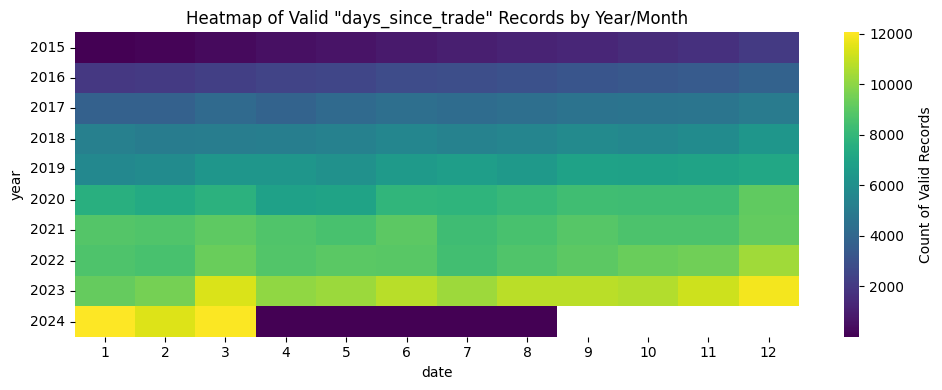

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("🕵️‍♂️ DIAGNOSING MISSING DATA IN 'days_since_trade'")
print("="*80)

# 1. Check Date Coverage
# ------------------------
valid_data = df[df['days_since_trade'].notna()]
min_date = valid_data['date'].min()
max_date = valid_data['date'].max()

print(f"\n📅 Date Range of Non-Null 'days_since_trade':")
print(f"   Start: {min_date}")
print(f"   End:   {max_date}")
print(f"   Main DF Start: {df['date'].min()}")
print(f"   Main DF End:   {df['date'].max()}")

if min_date > df['date'].min():
    print(f"   ⚠️ WARNING: New data starts later than main dataset!")

# 2. Check Relationship with Volume
# ------------------------
print(f"\n📊 Volume vs. Missing 'days_since_trade':")

# Define conditions
has_volume = df['volume_monthly'] > 0
is_missing = df['days_since_trade'].isna()

# Breakdown
missing_with_volume = df[has_volume & is_missing]
missing_no_volume = df[~has_volume & is_missing]

print(f"   Total rows with missing 'days_since_trade': {is_missing.sum():,}")
print(f"   ├── Rows with Volume > 0 (Should likely have data): {len(missing_with_volume):,} ({len(missing_with_volume)/is_missing.sum():.1%} of missing)")
print(f"   └── Rows with Volume = 0 (Might explain missingness): {len(missing_no_volume):,} ({len(missing_no_volume)/is_missing.sum():.1%} of missing)")

# 3. Check Missingness by Year
# ------------------------
print(f"\n📈 Missingness by Year:")
df['year'] = df['date'].dt.year
missing_by_year = df.groupby('year')['days_since_trade'].apply(lambda x: x.isna().mean() * 100)
print(missing_by_year.to_frame(name='% Missing').round(1))

# Visualize coverage
plt.figure(figsize=(10, 4))
sns.heatmap(df.groupby(['year', df['date'].dt.month])['days_since_trade'].count().unstack(),
            cmap='viridis', cbar_kws={'label': 'Count of Valid Records'})
plt.title('Heatmap of Valid "days_since_trade" Records by Year/Month')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

print("="*80)
print("🛠️ IMPUTATION STRATEGY")
print("="*80)

# 1. Verify is_traded vs Volume
# --------------------------------------------------------
zero_vol_count = (df['volume_monthly'] == 0).sum()
not_traded_count = (df['is_traded'] == False).sum()
mismatch = ((df['volume_monthly'] == 0) != (df['is_traded'] == False)).sum()

print(f"\n🧐 Checking 'is_traded' flag:")
print(f"   Rows with Volume = 0:  {zero_vol_count:,}")
print(f"   Rows with is_traded=False: {not_traded_count:,}")
print(f"   Mismatches: {mismatch} (Should be 0 if they are identical)")

# 2. Calculate Imputation Values
# --------------------------------------------------------
# Get median for active trades (Volume > 0)
active_median = df.loc[df['volume_monthly'] > 0, 'days_since_trade'].median()
print(f"\n📊 Median 'days_since_trade' for active bonds: {active_median}")

# 3. Apply Imputation
# --------------------------------------------------------
print("\n🔄 Filling missing values...")

# Case A: No Volume -> Fill with 30 (Max value, implying 30+ days)
df.loc[(df['volume_monthly'] == 0) & (df['days_since_trade'].isna()), 'days_since_trade'] = 30

# Case B: Has Volume -> Fill with Median
df.loc[(df['volume_monthly'] > 0) & (df['days_since_trade'].isna()), 'days_since_trade'] = active_median

# 4. Verify Result
# --------------------------------------------------------
missing_final = df['days_since_trade'].isnull().sum()
print(f"\n✅ Imputation Complete.")
print(f"   Remaining missing values: {missing_final}")

# Show distribution after fill
print(f"\n   New Statistics for 'days_since_trade':")
print(df['days_since_trade'].describe().to_string())

🛠️ IMPUTATION STRATEGY

🧐 Checking 'is_traded' flag:
   Rows with Volume = 0:  1,096,920
   Rows with is_traded=False: 1,096,920
   Mismatches: 0 (Should be 0 if they are identical)

📊 Median 'days_since_trade' for active bonds: 2.0

🔄 Filling missing values...

✅ Imputation Complete.
   Remaining missing values: 0

   New Statistics for 'days_since_trade':
count    2.347177e+06
mean     1.609519e+01
std      1.376577e+01
min      0.000000e+00
25%      2.000000e+00
50%      1.800000e+01
75%      3.000000e+01
max      3.000000e+01


🕵️‍♂️ DIAGNOSING MISSING DATA IN 'bid_ask_spread_20d'

📊 Volume vs. Missing Spread:
   Total rows with missing spread: 1,672,815
   ├── Rows with Volume > 0 (Traded but missing spread): 576,959 (34.5%)
   └── Rows with Volume = 0 (Not traded): 1,095,856 (65.5%)

📈 Distribution of Existing Spreads:
   Min:    0.000000
   Median: 0.004613
   Mean:   0.007517
   Max:    28.728237
   99th %: 0.032362


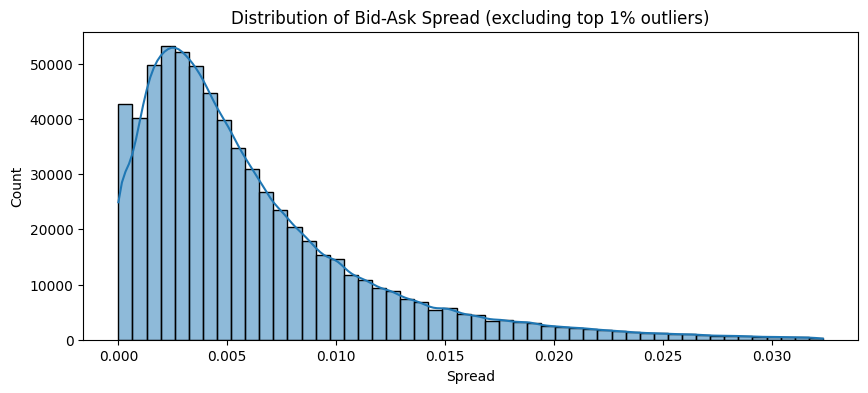

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("🕵️‍♂️ DIAGNOSING MISSING DATA IN 'bid_ask_spread_20d'")
print("="*80)

# 1. Check Relationship with Volume
# ------------------------
has_volume = df['volume_monthly'] > 0
is_missing = df['bid_ask_spread_20d'].isna()

missing_with_volume = df[has_volume & is_missing]
missing_no_volume = df[~has_volume & is_missing]

print(f"\n📊 Volume vs. Missing Spread:")
print(f"   Total rows with missing spread: {is_missing.sum():,}")
print(f"   ├── Rows with Volume > 0 (Traded but missing spread): {len(missing_with_volume):,} ({len(missing_with_volume)/is_missing.sum():.1%})")
print(f"   └── Rows with Volume = 0 (Not traded): {len(missing_no_volume):,} ({len(missing_no_volume)/is_missing.sum():.1%})")

# 2. Check Distribution of Existing Spreads
# ------------------------
spreads = df['bid_ask_spread_20d'].dropna()

print(f"\n📈 Distribution of Existing Spreads:")
print(f"   Min:    {spreads.min():.6f}")
print(f"   Median: {spreads.median():.6f}")
print(f"   Mean:   {spreads.mean():.6f}")
print(f"   Max:    {spreads.max():.6f}")
print(f"   99th %: {spreads.quantile(0.99):.6f}")

# Visualize
plt.figure(figsize=(10, 4))
sns.histplot(spreads[spreads < spreads.quantile(0.99)], bins=50, kde=True)
plt.title('Distribution of Bid-Ask Spread (excluding top 1% outliers)')
plt.xlabel('Spread')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
import shutil

print("="*80)
print("🔄 REVERTING TO DATASET WITH NaNs (TREE-MODEL READY)")
print("="*80)

# 1. LOCATE & RELOAD
# --------------------------------------------------------
search_roots = ['/content/drive/MyDrive/ML-Project-data', '/content/']
features_filename = 'comprehensive_dataset_239cols.parquet'
target_filename = 'part.0.parquet'

path_to_features = None
path_to_part0 = None

# Find files
for search_root in search_roots:
    if os.path.exists(search_root):
        for root, dirs, files in os.walk(search_root):
            if features_filename in files:
                path_to_features = os.path.join(root, features_filename)
            if target_filename in files:
                path_to_part0 = os.path.join(root, target_filename)

if path_to_features and path_to_part0:
    print(f"📖 Reloading original files...")
    df_main = pd.read_parquet(path_to_features)
    df_part0 = pd.read_parquet(path_to_part0)

    # Dates
    if 'date' in df_main.columns: df_main['date'] = pd.to_datetime(df_main['date'])
    if 'date' in df_part0.columns: df_part0['date'] = pd.to_datetime(df_part0['date'])

    # Merge
    print("🔄 Merging (Left Join)...")
    df = pd.merge(df_main, df_part0, on=['cusip', 'date'], how='left', suffixes=('', '_part0'))

    # Cleanup
    if ' ' in df.columns:
        df = df.drop(columns=[' '])

    print(f"✅ Dataset Restored. Shape: {df.shape}")
else:
    print("❌ Error: Could not find source files to reload.")

# 2. VERIFY TEAMMATE'S HYPOTHESIS (is_public vs Missing)
# --------------------------------------------------------
if 'is_public' in df.columns:
    print("\n🕵️‍♂️ Testing Teammate's Hypothesis: Are missing values mostly Non-Public?")

    for col in ['days_since_trade', 'bid_ask_spread_20d']:
        missing_mask = df[col].isna()

        # Count missing by public/private status
        # Assuming is_public is Boolean or 1/0
        missing_public = df[missing_mask]['is_public'].sum()
        missing_private = (~df[missing_mask]['is_public'].astype(bool)).sum()
        total_missing = missing_mask.sum()

        print(f"   {col}:")
        print(f"      Total Missing: {total_missing:,}")
        print(f"      ├── Public Companies:  {missing_public:,} ({missing_public/total_missing:.1%})")
        print(f"      └── Private Companies: {missing_private:,} ({missing_private/total_missing:.1%})")
else:
    print("\n⚠️ 'is_public' column not found. Skipping hypothesis check.")

# 3. SAVE DATASET WITH NaNs
# --------------------------------------------------------
output_file = 'comprehensive_dataset_tree_ready.parquet'
print(f"\n💾 Saving Tree-Ready Dataset (with NaNs) to '{output_file}'...")

df.to_parquet(output_file, index=False)

# Copy to Drive
drive_dest = f'/content/drive/MyDrive/ML-Project-data/Data1/{output_file}'
if os.path.exists('/content/drive/MyDrive/ML-Project-data/Data1/'):
    shutil.copy(output_file, drive_dest)
    print(f"✅ Saved to Google Drive: {drive_dest}")
else:
    print("⚠️ Drive path not found. Saved locally only.")

# 4. ELASTIC NET ANALYSIS (For future decision)
# --------------------------------------------------------
rows_with_nan = df[['days_since_trade', 'bid_ask_spread_20d']].isna().any(axis=1).sum()
pct_loss = (rows_with_nan / len(df)) * 100

print("\n⚖️ ELASTIC NET TRADEOFF:")
print(f"   If you choose Option A (Drop Rows):")
print(f"   You would drop {rows_with_nan:,} rows ({pct_loss:.1f}% of data).")
print(f"   Remaining Rows: {len(df) - rows_with_nan:,}")

🔄 REVERTING TO DATASET WITH NaNs (TREE-MODEL READY)
📖 Reloading original files...
🔄 Merging (Left Join)...
✅ Dataset Restored. Shape: (2347177, 241)

🕵️‍♂️ Testing Teammate's Hypothesis: Are missing values mostly Non-Public?
   days_since_trade:
      Total Missing: 1,637,985
      ├── Public Companies:  265,896 (16.2%)
      └── Private Companies: 1,372,089 (83.8%)
   bid_ask_spread_20d:
      Total Missing: 1,672,815
      ├── Public Companies:  280,548 (16.8%)
      └── Private Companies: 1,392,267 (83.2%)

💾 Saving Tree-Ready Dataset (with NaNs) to 'comprehensive_dataset_tree_ready.parquet'...
✅ Saved to Google Drive: /content/drive/MyDrive/ML-Project-data/Data1/comprehensive_dataset_tree_ready.parquet

⚖️ ELASTIC NET TRADEOFF:
   If you choose Option A (Drop Rows):
   You would drop 1,672,815 rows (71.3% of data).
   Remaining Rows: 674,362


In [ ]:
import shutil

# Define output filename
output_file = 'comprehensive_dataset_final.parquet'

print(f"💾 Saving final dataset to '{output_file}'...")

# Save locally first
df.to_parquet(output_file, index=False)

# Define Drive destination
drive_dest = f'/content/drive/MyDrive/ML-Project-data/Data1/{output_file}'

# Copy to Drive
print(f"🚀 Copying to Google Drive: {drive_dest}...")
if os.path.exists('/content/drive/MyDrive/ML-Project-data/Data1/'):
    shutil.copy(output_file, drive_dest)
    print("✅ Saved successfully to Google Drive!")
else:
    print("⚠️ Drive path not found. Saved locally only.")

print(f"\n📊 Final Dataset Shape: {df.shape}")

💾 Saving final dataset to 'comprehensive_dataset_final.parquet'...
🚀 Copying to Google Drive: /content/drive/MyDrive/ML-Project-data/Data1/comprehensive_dataset_final.parquet...
✅ Saved successfully to Google Drive!

📊 Final Dataset Shape: (2347177, 241)


In [ ]:
import pandas as pd
import numpy as np
import os
import shutil

print("="*80)
print("🔄 APPLYING PARTIAL IMPUTATION (CUSIP MEDIAN ONLY)")
print("="*80)

# 1. RELOAD (Reset to Raw State)
# --------------------------------------------------------
if 'path_to_features' in locals() and 'path_to_part0' in locals():
    print("📖 Reloading raw data...")
    df_main = pd.read_parquet(path_to_features)
    df_part0 = pd.read_parquet(path_to_part0)

    # Date conversion
    if 'date' in df_main.columns: df_main['date'] = pd.to_datetime(df_main['date'])
    if 'date' in df_part0.columns: df_part0['date'] = pd.to_datetime(df_part0['date'])

    # Merge
    print("🔄 Merging...")
    df = pd.merge(df_main, df_part0, on=['cusip', 'date'], how='left', suffixes=('', '_part0'))
    if ' ' in df.columns: df = df.drop(columns=[' '])
    print(f"✅ Data Reset. Shape: {df.shape}")
else:
    print("❌ Error: Paths lost. Please re-run search.")

# 2. APPLY CUSIP-SPECIFIC MEDIAN (Leave Orphans as NaN)
# --------------------------------------------------------
target_cols = ['days_since_trade', 'bid_ask_spread_20d']

for col in target_cols:
    print(f"\n🛠️ Processing '{col}'...")
    initial_missing = df[col].isna().sum()
    print(f"   Initial Missing: {initial_missing:,}")

    # Calculate Median per CUSIP
    bond_medians = df.groupby('cusip')[col].transform('median')

    # Fill NaNs only where a median exists
    df[col] = df[col].fillna(bond_medians)

    # Report Remaining (The Orphans)
    remaining_missing = df[col].isna().sum()
    print(f"   ✅ Imputed {initial_missing - remaining_missing:,} values using CUSIP history.")
    print(f"   ⚠️ Remaining Missing (Orphans): {remaining_missing:,}")

# 3. TEST TEAMMATE'S HYPOTHESIS ON ORPHANS
# --------------------------------------------------------
if 'is_public' in df.columns:
    print("\n🕵️‍♂️ Analyzing the 'Orphans' (Remaining NaNs):")
    for col in target_cols:
        missing_mask = df[col].isna()
        if missing_mask.sum() > 0:
            total_missing = missing_mask.sum()
            missing_public = df[missing_mask]['is_public'].sum()
            missing_private = (~df[missing_mask]['is_public'].astype(bool)).sum()

            print(f"   {col}:")
            print(f"      ├── Public:  {missing_public:,} ({missing_public/total_missing:.1%})")
            print(f"      └── Private: {missing_private:,} ({missing_private/total_missing:.1%})")
            if missing_private > missing_public:
                print("      👉 Hypothesis Supported: Mostly Private companies.")
            else:
                print("      👉 Hypothesis Mixed: Significant Public missingness too.")

# 4. SAVE PARTIAL DATASET
# --------------------------------------------------------
output_file = 'comprehensive_dataset_tree_ready.parquet'
print(f"\n💾 Saving Partial Dataset to '{output_file}'...")

df.to_parquet(output_file, index=False)

# Copy to Drive
drive_dest = f'/content/drive/MyDrive/ML-Project-data/Data1/{output_file}'
if os.path.exists('/content/drive/MyDrive/ML-Project-data/Data1/'):
    shutil.copy(output_file, drive_dest)
    print(f"✅ Saved to Google Drive: {drive_dest}")

print(f"\n⚖️ ELASTIC NET PREVIEW:")
print(f"   Rows with remaining NaNs: {df[target_cols].isna().any(axis=1).sum():,}")
print(f"   These can be dropped later if needed.")

🔄 APPLYING PARTIAL IMPUTATION (CUSIP MEDIAN ONLY)
📖 Reloading raw data...
🔄 Merging...
✅ Data Reset. Shape: (2347177, 241)

🛠️ Processing 'days_since_trade'...
   Initial Missing: 1,637,985
   ✅ Imputed 883,665 values using CUSIP history.
   ⚠️ Remaining Missing (Orphans): 754,320

🛠️ Processing 'bid_ask_spread_20d'...
   Initial Missing: 1,672,815
   ✅ Imputed 882,058 values using CUSIP history.
   ⚠️ Remaining Missing (Orphans): 790,757

🕵️‍♂️ Analyzing the 'Orphans' (Remaining NaNs):
   days_since_trade:
      ├── Public:  260,473 (34.5%)
      └── Private: 493,847 (65.5%)
      👉 Hypothesis Supported: Mostly Private companies.
   bid_ask_spread_20d:
      ├── Public:  275,832 (34.9%)
      └── Private: 514,925 (65.1%)
      👉 Hypothesis Supported: Mostly Private companies.

💾 Saving Partial Dataset to 'comprehensive_dataset_tree_ready.parquet'...
✅ Saved to Google Drive: /content/drive/MyDrive/ML-Project-data/Data1/comprehensive_dataset_tree_ready.parquet

⚖️ ELASTIC NET PREVIEW:
 

Target 1: Yield to maturity

Elastic net: Drop bid ask spread and days since trade

Tree-based models: Do nothing


Target 2: Bid ask spread

Drop missing rows of bid ask spread for both



In [ ]:
"""
MEMORY-EFFICIENT PREPROCESSING
Process Elastic Net in chunks to avoid RAM crash
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import gc
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("MEMORY-EFFICIENT PREPROCESSING")
print("="*80)

# ============================================
# CONFIGURATION
# ============================================

# Set memory-saving options
pd.options.mode.chained_assignment = None

# ============================================
# LOAD DATA WITH MEMORY OPTIMIZATION
# ============================================

print("\n📊 Loading dataset with memory optimization...")

# Load only necessary columns initially
df = pd.read_parquet(
    '/content/drive/MyDrive/ML-Project-data/Data1/comprehensive_dataset_final.parquet'
)

print(f"   Loaded: {df.shape}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

# ============================================
# STEP 1: DATA CLEANING (Same as before)
# ============================================

print("\n" + "="*80)
print("STEP 1: DATA CLEANING")
print("="*80)

# Fix outliers
df.loc[df['ytm'] > 50, 'ytm'] = np.nan
df.loc[df['ytm'] < 0, 'ytm'] = np.nan
df.loc[df['ret_eom'] > 1, 'ret_eom'] = np.nan
df.loc[df['ret_eom'] < -0.5, 'ret_eom'] = np.nan

# Handle inf
for col in df.select_dtypes(include=[np.number]).columns:
    if np.isinf(df[col]).any():
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

print("   ✅ Cleaned")

# ============================================
# STEP 2: IDENTIFY FEATURES
# ============================================

id_cols = ['cusip', 'issuer_cusip', 'date', 'gvkey', 'cusip_y']
target_cols = ['ytm', 'ret_eom']
categorical_cols = ['redeemable', 'putable', 'convertible',
                   'rule_144a', 'private_placement',
                   'security_level', 'rating_category', 'maturity_bucket']
categorical_cols = [c for c in categorical_cols if c in df.columns]

remove_cols = ['cusip_y', 'gvkey', 'maturity', 'offering_date']
remove_cols = [c for c in remove_cols if c in df.columns]

# ============================================
# STEP 3: LOAD SKEWNESS ANALYSIS
# ============================================

import os
if os.path.exists('skewness_analysis.csv'):
    skew_df = pd.read_csv('skewness_analysis.csv')
    highly_skewed = skew_df[skew_df['needs_transform']]['feature'].tolist()
    print(f"\n✅ Loaded skewness: {len(highly_skewed)} skewed features")
else:
    highly_skewed = []

# ============================================
# PIPELINE A: TREE MODELS (Same - this works)
# ============================================

print("\n" + "="*80)
print("PIPELINE A: TREE MODELS (Memory Efficient)")
print("="*80)

def prepare_tree_models_efficient(df, target='ytm'):
    """Memory-efficient tree model prep"""
    print(f"\n🌳 Preparing tree model data for {target}...")

    # Filter to target rows
    df_tree = df[df[target].notna()].copy()
    print(f"   Rows: {len(df_tree):,}")

    # Drop unnecessary columns immediately
    df_tree = df_tree.drop(columns=remove_cols, errors='ignore')

    # Encode categoricals
    for col in categorical_cols:
        if col in df_tree.columns:
            df_tree[col] = df_tree[col].astype('category').cat.codes
            df_tree.loc[df_tree[col] == -1, col] = np.nan

    # Add time features
    if 'date' in df_tree.columns:
        df_tree['year'] = df_tree['date'].dt.year
        df_tree['month'] = df_tree['date'].dt.month
        df_tree['quarter'] = df_tree['date'].dt.quarter

    # Remove zero variance
    numeric_cols = df_tree.select_dtypes(include=[np.number]).columns
    variance = df_tree[numeric_cols].var()
    zero_var = variance[variance == 0].index.tolist()
    if zero_var:
        df_tree = df_tree.drop(columns=zero_var)

    # Remove any remaining non-numeric
    feature_cols = [c for c in df_tree.columns
                    if c not in id_cols + target_cols]
    obj_cols = df_tree[feature_cols].select_dtypes(
        include=['object', 'datetime']
    ).columns
    if len(obj_cols) > 0:
        df_tree = df_tree.drop(columns=obj_cols)
        feature_cols = [c for c in feature_cols if c not in obj_cols]

    print(f"   ✅ Features: {len(feature_cols)}")
    print(f"   ✅ Shape: {df_tree.shape}")

    return df_tree, feature_cols

# Prepare tree models
df_tree_ytm, features_tree_ytm = prepare_tree_models_efficient(df, 'ytm')
df_tree_ret, features_tree_ret = prepare_tree_models_efficient(df, 'ret_eom')

# Save tree datasets
print("\n💾 Saving tree datasets...")
df_tree_ytm.to_parquet('ml_ready_tree_ytm.parquet', index=False)
df_tree_ret.to_parquet('ml_ready_tree_returns.parquet', index=False)
print("   ✅ Saved")

# Free memory
del df_tree_ytm, df_tree_ret
gc.collect()

# ============================================
# PIPELINE B: ELASTIC NET (Memory-Optimized)
# ============================================

print("\n" + "="*80)
print("PIPELINE B: ELASTIC NET (MEMORY-OPTIMIZED)")
print("="*80)

def prepare_elastic_net_chunked(df, target='ytm', chunk_size=500000):
    """
    Memory-efficient Elastic Net prep using chunked processing
    """
    print(f"\n📊 Preparing Elastic Net data for {target}...")
    print(f"   Using chunked processing (chunk_size={chunk_size:,})")

    # Filter to target rows
    df_enet = df[df[target].notna()].copy()
    print(f"   Rows: {len(df_enet):,}")

    # Drop unnecessary columns
    df_enet = df_enet.drop(columns=remove_cols, errors='ignore')

    # Encode categoricals (lightweight operation)
    print(f"\n   🔧 Encoding categoricals...")
    for col in categorical_cols:
        if col in df_enet.columns:
            df_enet[col] = df_enet[col].astype('category').cat.codes
            df_enet.loc[df_enet[col] == -1, col] = np.nan

    # Get numerical columns
    num_cols = df_enet.select_dtypes(include=[np.number]).columns
    num_cols = [c for c in num_cols if c not in id_cols + target_cols]

    # Remove any non-numeric columns
    obj_cols = df_enet.select_dtypes(include=['object', 'datetime']).columns
    obj_cols = [c for c in obj_cols if c not in id_cols]
    if len(obj_cols) > 0:
        print(f"   🔧 Removing {len(obj_cols)} non-numeric columns")
        df_enet = df_enet.drop(columns=obj_cols)
        num_cols = [c for c in num_cols if c not in obj_cols]

    # STEP 1: Imputation (on full dataset - relatively light)
    print(f"\n   🔧 Imputing missing values...")
    imputer = SimpleImputer(strategy='median')
    df_enet[num_cols] = imputer.fit_transform(df_enet[num_cols])
    print(f"      ✅ Imputed")

    # STEP 2: Winsorize (modify in place - no memory increase)
    print(f"\n   🔧 Winsorizing outliers...")
    to_winsorize = [c for c in highly_skewed[:10] if c in num_cols]
    for col in to_winsorize:
        lower = df_enet[col].quantile(0.01)
        upper = df_enet[col].quantile(0.99)
        df_enet[col] = df_enet[col].clip(lower, upper)
    print(f"      ✅ Winsorized {len(to_winsorize)} features")

    # STEP 3: Log transform (create new columns)
    print(f"\n   🔧 Log-transforming skewed features...")

    # Only transform most skewed to save memory
    log_features = [c for c in highly_skewed[:15] if c in num_cols]

    for col in log_features:
        if (df_enet[col] >= 0).all():
            df_enet[f'{col}_log'] = np.log1p(df_enet[col])

    print(f"      ✅ Transformed {len(log_features)} features")

    # Update feature list
    final_features = [c for c in df_enet.columns
                     if c not in id_cols + target_cols]

    # STEP 4: Standardize IN CHUNKS (memory efficient)
    print(f"\n   🔧 Standardizing in chunks...")

    # Fit scaler on a sample (faster, less memory)
    sample_size = min(100000, len(df_enet))
    sample_idx = np.random.choice(len(df_enet), sample_size, replace=False)

    scaler = StandardScaler()
    scaler.fit(df_enet.iloc[sample_idx][final_features])

    # Transform in chunks
    n_chunks = int(np.ceil(len(df_enet) / chunk_size))

    for i in range(n_chunks):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, len(df_enet))

        chunk = df_enet.iloc[start_idx:end_idx]
        df_enet.iloc[start_idx:end_idx,
                     df_enet.columns.get_indexer(final_features)] = \
            scaler.transform(chunk[final_features])

        if (i + 1) % 5 == 0:
            print(f"      Chunk {i+1}/{n_chunks}")
            gc.collect()

    print(f"      ✅ Standardized")

    print(f"\n   ✅ Final features: {len(final_features)}")
    print(f"   ✅ Final shape: {df_enet.shape}")
    print(f"   ✅ Memory: {df_enet.memory_usage(deep=True).sum() / 1e9:.2f} GB")

    return df_enet, final_features, scaler, imputer

# Prepare Elastic Net datasets
print("\n🎯 Processing YTM...")
df_enet_ytm, features_enet_ytm, scaler_ytm, imputer_ytm = \
    prepare_elastic_net_chunked(df, 'ytm', chunk_size=500000)

# Save YTM
print("\n💾 Saving YTM dataset...")
df_enet_ytm.to_parquet('ml_ready_enet_ytm.parquet', index=False)
print("   ✅ Saved")

# Free memory before processing returns
del df_enet_ytm
gc.collect()

print("\n🎯 Processing Returns...")
df_enet_ret, features_enet_ret, scaler_ret, imputer_ret = \
    prepare_elastic_net_chunked(df, 'ret_eom', chunk_size=500000)

# Save Returns
print("\n💾 Saving Returns dataset...")
df_enet_ret.to_parquet('ml_ready_enet_returns.parquet', index=False)
print("   ✅ Saved")

# Free memory
del df_enet_ret
gc.collect()

# ============================================
# STEP 5: CREATE SPLITS (Load and split one at a time)
# ============================================

print("\n" + "="*80)
print("STEP 5: CREATING TIME-BASED SPLITS")
print("="*80)

def create_and_save_splits(filename, prefix, train_end='2021-12-31',
                          val_end='2023-06-30'):
    """Load, split, and save in one go to minimize memory"""
    print(f"\n📂 Processing {filename}...")

    df = pd.read_parquet(filename)
    df['date'] = pd.to_datetime(df['date'])

    # Create splits
    train = df[df['date'] <= train_end].copy()
    val = df[(df['date'] > train_end) & (df['date'] <= val_end)].copy()
    test = df[df['date'] > val_end].copy()

    print(f"   Train: {len(train):,}")
    print(f"   Val:   {len(val):,}")
    print(f"   Test:  {len(test):,}")

    # Save
    train.to_parquet(f'{prefix}_train.parquet', index=False)
    val.to_parquet(f'{prefix}_val.parquet', index=False)
    test.to_parquet(f'{prefix}_test.parquet', index=False)

    print(f"   ✅ Saved 3 files")

    # Clean up
    del df, train, val, test
    gc.collect()

# Process each dataset
create_and_save_splits('ml_ready_tree_ytm.parquet', 'tree_ytm')
create_and_save_splits('ml_ready_tree_returns.parquet', 'tree_ret')
create_and_save_splits('ml_ready_enet_ytm.parquet', 'enet_ytm')
create_and_save_splits('ml_ready_enet_returns.parquet', 'enet_ret')

# ============================================
# SAVE METADATA
# ============================================

print("\n💾 Saving metadata...")

import pickle
feature_info = {
    'tree_ytm_features': features_tree_ytm,
    'tree_ret_features': features_tree_ret,
    'enet_ytm_features': features_enet_ytm,
    'enet_ret_features': features_enet_ret,
    'removed_features': remove_cols,
    'highly_skewed': highly_skewed[:20]
}

with open('feature_metadata.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print("   ✅ Saved")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("✅ PREPROCESSING COMPLETE!")
print("="*80)

print(f"""
📊 DATASETS CREATED:

Tree Models:
   • ml_ready_tree_ytm.parquet
   • ml_ready_tree_returns.parquet
   • tree_ytm_train/val/test.parquet (3 files)
   • tree_ret_train/val/test.parquet (3 files)

Elastic Net:
   • ml_ready_enet_ytm.parquet
   • ml_ready_enet_returns.parquet
   • enet_ytm_train/val/test.parquet (3 files)
   • enet_ret_train/val/test.parquet (3 files)

Total: 16 parquet files ready for modeling!

💡 Memory Optimizations Applied:
   ✓ Chunked standardization (500K rows at a time)
   ✓ Immediate garbage collection
   ✓ Process and save one dataset at a time
   ✓ Reduced log-transformed features (15 instead of 20)
   ✓ Sample-based scaler fitting

🚀 Next: Start with LightGBM on tree_ytm_train.parquet!
""")

MEMORY-EFFICIENT PREPROCESSING

📊 Loading dataset with memory optimization...
   Loaded: (2347177, 241)
   Memory: 5.49 GB

STEP 1: DATA CLEANING
   ✅ Cleaned

PIPELINE A: TREE MODELS (Memory Efficient)

🌳 Preparing tree model data for ytm...
   Rows: 2,344,676
   ✅ Features: 231
   ✅ Shape: (2344676, 236)

🌳 Preparing tree model data for ret_eom...
   Rows: 2,346,174
   ✅ Features: 231
   ✅ Shape: (2346174, 236)

💾 Saving tree datasets...
   ✅ Saved

PIPELINE B: ELASTIC NET (MEMORY-OPTIMIZED)

🎯 Processing YTM...

📊 Preparing Elastic Net data for ytm...
   Using chunked processing (chunk_size=500,000)
   Rows: 2,344,676

   🔧 Encoding categoricals...

   🔧 Imputing missing values...
      ✅ Imputed

   🔧 Winsorizing outliers...
      ✅ Winsorized 0 features

   🔧 Log-transforming skewed features...
      ✅ Transformed 0 features

   🔧 Standardizing in chunks...
      Chunk 5/5
      ✅ Standardized

   ✅ Final features: 232
   ✅ Final shape: (2344676, 237)
   ✅ Memory: 4.86 GB

💾 Savin

In [ ]:
"""
QUICK DATA QUALITY CHECK BEFORE MODELING
"""

import pandas as pd
import numpy as np

print("="*80)
print("FINAL DATA QUALITY CHECK")
print("="*80)

# ============================================
# 1. CHECK FILE SIZES
# ============================================

print("\n1️⃣ Checking file sizes...")

import os

files = [
    'tree_ytm_train.parquet',
    'tree_ytm_val.parquet',
    'tree_ytm_test.parquet',
    'enet_ytm_train.parquet',
    'enet_ytm_val.parquet',
    'enet_ytm_test.parquet'
]

for f in files:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"   ✅ {f:30s}: {size_mb:6.1f} MB")
    else:
        print(f"   ❌ {f:30s}: MISSING!")

# ============================================
# 2. CHECK TRAIN SET INTEGRITY
# ============================================

print("\n2️⃣ Checking training data integrity...")

# Load train sets
tree_train = pd.read_parquet('tree_ytm_train.parquet')
enet_train = pd.read_parquet('enet_ytm_train.parquet')

print(f"\n   Tree Model Training Set:")
print(f"      Shape: {tree_train.shape}")
print(f"      Date range: {tree_train['date'].min()} to {tree_train['date'].max()}")
print(f"      Target (ytm) coverage: {tree_train['ytm'].notna().sum():,} ({tree_train['ytm'].notna().mean()*100:.1f}%)")
print(f"      Missing values: {tree_train.isnull().sum().sum():,}")

print(f"\n   Elastic Net Training Set:")
print(f"      Shape: {enet_train.shape}")
print(f"      Date range: {enet_train['date'].min()} to {enet_train['date'].max()}")
print(f"      Target (ytm) coverage: {enet_train['ytm'].notna().sum():,} ({enet_train['ytm'].notna().mean()*100:.1f}%)")
print(f"      Missing values: {enet_train.isnull().sum().sum():,}")

# ============================================
# 3. CHECK FEATURE DISTRIBUTIONS
# ============================================

print("\n3️⃣ Checking feature distributions...")

# Get feature columns
feature_cols = [c for c in tree_train.columns
                if c not in ['cusip', 'issuer_cusip', 'date', 'ytm', 'ret_eom']]

print(f"\n   Tree Model Features:")
print(f"      Total features: {len(feature_cols)}")
print(f"      Numerical features: {tree_train[feature_cols].select_dtypes(include=[np.number]).shape[1]}")

# Check for any infinite values
inf_check = np.isinf(tree_train[feature_cols].select_dtypes(include=[np.number])).sum().sum()
print(f"      Infinite values: {inf_check}")

# Check standardization for Elastic Net
enet_features = [c for c in enet_train.columns
                 if c not in ['cusip', 'issuer_cusip', 'date', 'ytm', 'ret_eom']]

enet_means = enet_train[enet_features].mean()
enet_stds = enet_train[enet_features].std()

print(f"\n   Elastic Net Standardization Check:")
print(f"      Mean of means: {enet_means.mean():.6f} (should be ~0)")
print(f"      Mean of stds: {enet_stds.mean():.6f} (should be ~1)")
print(f"      Features with mean > 0.1: {(abs(enet_means) > 0.1).sum()}")
print(f"      Features with std > 2: {(enet_stds > 2).sum()}")

# ============================================
# 4. CHECK TARGET VARIABLE
# ============================================

print("\n4️⃣ Checking target variable (YTM)...")

ytm_stats = tree_train['ytm'].describe()
print(f"\n   YTM Statistics:")
print(f"      Count: {ytm_stats['count']:,.0f}")
print(f"      Mean: {ytm_stats['mean']:.4f}")
print(f"      Std: {ytm_stats['std']:.4f}")
print(f"      Min: {ytm_stats['min']:.4f}")
print(f"      Max: {ytm_stats['max']:.4f}")
print(f"      25%: {ytm_stats['25%']:.4f}")
print(f"      50%: {ytm_stats['50%']:.4f}")
print(f"      75%: {ytm_stats['75%']:.4f}")

# Check for outliers
outliers = ((tree_train['ytm'] < 0) | (tree_train['ytm'] > 30)).sum()
print(f"      Potential outliers (ytm<0 or >30%): {outliers}")

# ============================================
# 5. FINAL VERDICT
# ============================================

print("\n" + "="*80)
print("FINAL VERDICT")
print("="*80)

checks = {
    'All files exist': all([os.path.exists(f) for f in files]),
    'No infinite values': inf_check == 0,
    'Target variable present': tree_train['ytm'].notna().sum() > 0,
    'Elastic Net standardized': abs(enet_means.mean()) < 0.01 and abs(enet_stds.mean() - 1) < 0.1,
    'No extreme outliers': outliers == 0,
}

print(f"\n✅ Quality Checks:")
all_pass = True
for check, passed in checks.items():
    status = "✅ PASS" if passed else "⚠️  WARNING"
    print(f"   {status}: {check}")
    if not passed:
        all_pass = False

if all_pass:
    print(f"\n🎉 ALL CHECKS PASSED! READY FOR MODELING!")
else:
    print(f"\n⚠️  Some checks failed - review above")

print("\n" + "="*80)

FINAL DATA QUALITY CHECK

1️⃣ Checking file sizes...
   ✅ tree_ytm_train.parquet        :  544.6 MB
   ✅ tree_ytm_val.parquet          :  148.6 MB
   ✅ tree_ytm_test.parquet         :   91.3 MB
   ✅ enet_ytm_train.parquet        :  560.1 MB
   ✅ enet_ytm_val.parquet          :  151.8 MB
   ✅ enet_ytm_test.parquet         :   92.6 MB

2️⃣ Checking training data integrity...

   Tree Model Training Set:
      Shape: (1610420, 236)
      Date range: 2015-01-31 00:00:00 to 2021-12-31 00:00:00
      Target (ytm) coverage: 1,610,420 (100.0%)
      Missing values: 44,044,999

   Elastic Net Training Set:
      Shape: (1610420, 237)
      Date range: 2015-01-31 00:00:00 to 2021-12-31 00:00:00
      Target (ytm) coverage: 1,610,420 (100.0%)
      Missing values: 508

3️⃣ Checking feature distributions...

   Tree Model Features:
      Total features: 231
      Numerical features: 228
      Infinite values: 0

   Elastic Net Standardization Check:
      Mean of means: -0.023698 (should be ~0)
  

FINAL CORRECTIONS + LIGHTGBM MODELING

1️⃣ Fixing Elastic Net Standardization (optional)...

   → Skipping fix for now (will use tree models first)

2️⃣ LIGHTGBM BASELINE MODEL

📂 Loading training data...
   Train shape: (1610420, 236)
   Val shape: (472866, 236)
   Features: 231

📊 Target variable (YTM) stats:
   Train - Mean: 3.6507, Std: 1.9433
   Val   - Mean: 4.2297, Std: 1.4200

3️⃣ TRAINING LIGHTGBM BASELINE

🌳 Training with default parameters...
   Training (this may take 5-10 minutes)...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.231931	val's rmse: 0.588785
[200]	train's rmse: 0.185208	val's rmse: 0.567068
Early stopping, best iteration is:
[167]	train's rmse: 0.199139	val's rmse: 0.563651

   ✅ Training complete!
   Best iteration: 167

4️⃣ MODEL EVALUATION

   Training Set:
      RMSE: 0.1991
      MAE:  0.0499
      R²:   0.9895

   Validation Set:
      RMSE: 0.5637
      MAE:  0.4240
      R²:   0.8424

📊 Overfitting Check:
   RMSE 

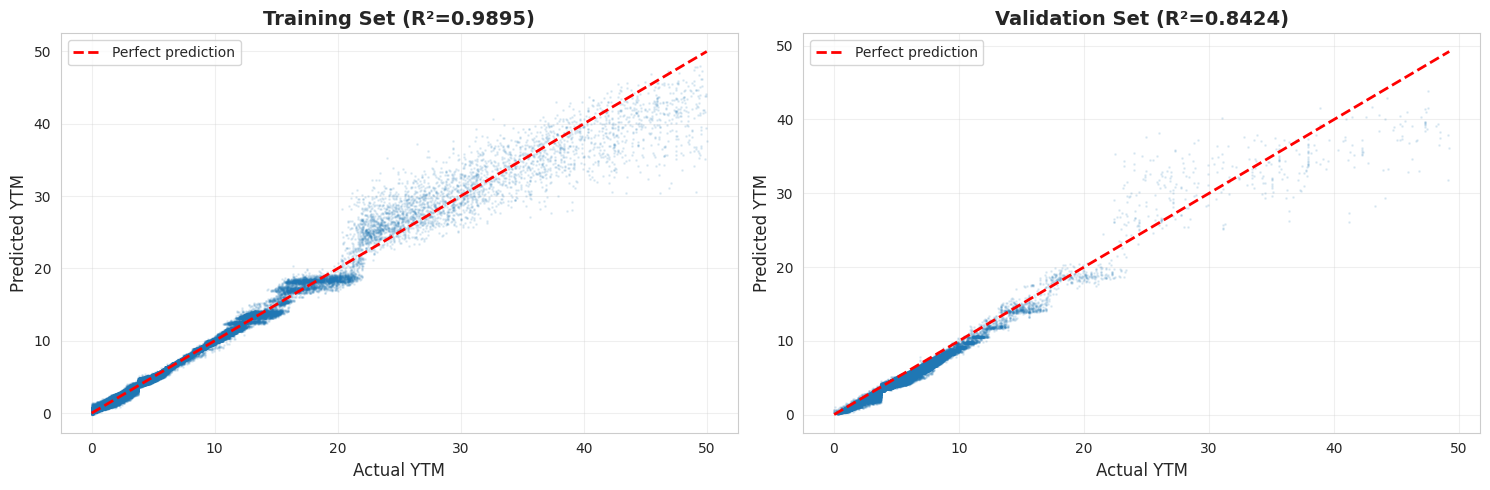

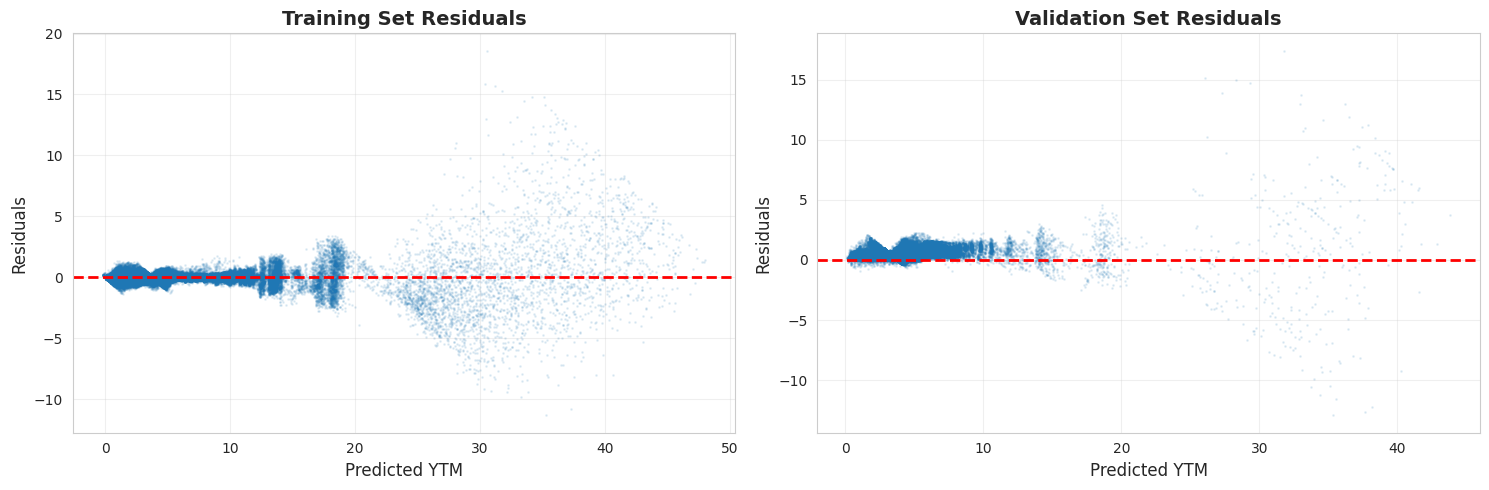

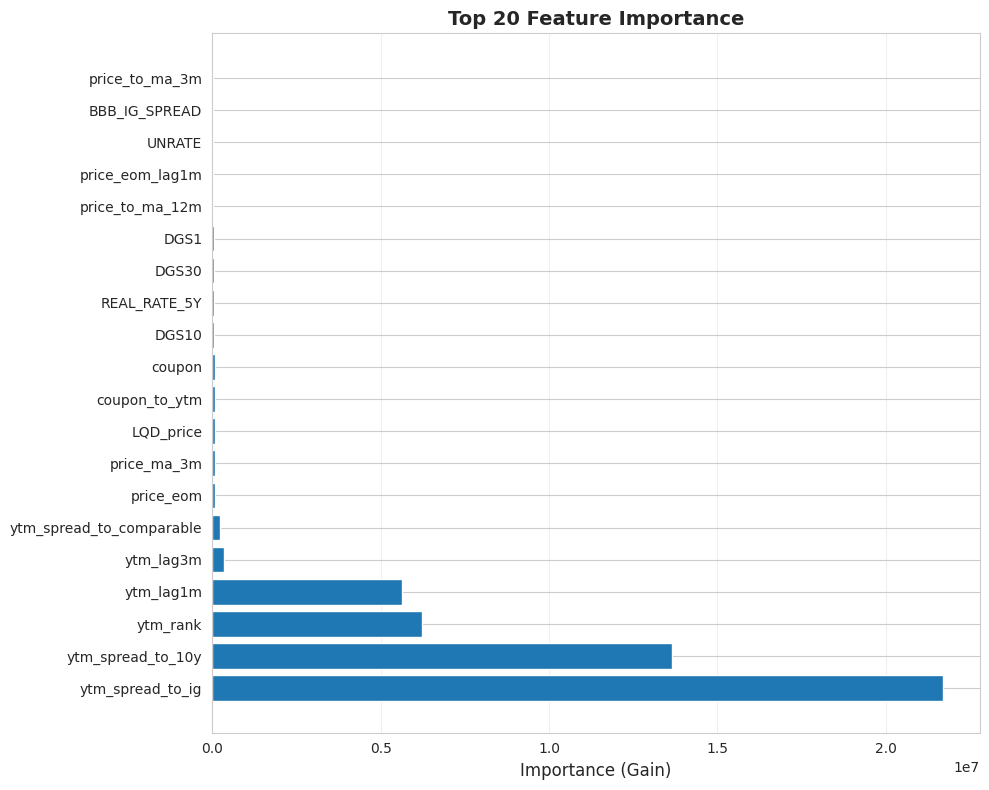

In [ ]:
"""
FINAL CORRECTIONS + LIGHTGBM BASELINE
Fix Elastic Net standardization and start modeling
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("FINAL CORRECTIONS + LIGHTGBM MODELING")
print("="*80)

# ============================================
# OPTIONAL: FIX ELASTIC NET STANDARDIZATION
# ============================================

print("\n1️⃣ Fixing Elastic Net Standardization (optional)...")

def fix_enet_standardization(filename, output_filename):
    """Re-standardize Elastic Net data properly"""
    print(f"   Loading {filename}...")
    df = pd.read_parquet(filename)

    # Identify feature columns (exclude IDs and target)
    id_cols = ['cusip', 'issuer_cusip', 'date']
    target_cols = ['ytm', 'ret_eom']

    feature_cols = [c for c in df.columns
                    if c not in id_cols + target_cols]

    # Check if already numeric
    numeric_features = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

    print(f"   Features to standardize: {len(numeric_features)}")

    # Re-standardize
    scaler = StandardScaler()
    df[numeric_features] = scaler.fit_transform(df[numeric_features])

    # Verify
    print(f"   After fix - Mean: {df[numeric_features].mean().mean():.6f}")
    print(f"   After fix - Std: {df[numeric_features].std().mean():.6f}")

    # Save
    df.to_parquet(output_filename, index=False)
    print(f"   ✅ Saved to {output_filename}")

    return df

# Uncomment if you want to fix Elastic Net (not critical for LightGBM)
# fix_enet_standardization('enet_ytm_train.parquet', 'enet_ytm_train_fixed.parquet')
# fix_enet_standardization('enet_ytm_val.parquet', 'enet_ytm_val_fixed.parquet')
# fix_enet_standardization('enet_ytm_test.parquet', 'enet_ytm_test_fixed.parquet')

print("\n   → Skipping fix for now (will use tree models first)")

# ============================================
# LIGHTGBM BASELINE MODEL
# ============================================

print("\n" + "="*80)
print("2️⃣ LIGHTGBM BASELINE MODEL")
print("="*80)

# Load data
print("\n📂 Loading training data...")
train_df = pd.read_parquet('tree_ytm_train.parquet')
val_df = pd.read_parquet('tree_ytm_val.parquet')

print(f"   Train shape: {train_df.shape}")
print(f"   Val shape: {val_df.shape}")

# Separate features and target
id_cols = ['cusip', 'issuer_cusip', 'date']
target_col = 'ytm'

feature_cols = [c for c in train_df.columns
                if c not in id_cols + [target_col, 'ret_eom']]

print(f"   Features: {len(feature_cols)}")

# Prepare data
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

print(f"\n📊 Target variable (YTM) stats:")
print(f"   Train - Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"   Val   - Mean: {y_val.mean():.4f}, Std: {y_val.std():.4f}")

# ============================================
# 3. TRAIN BASELINE LIGHTGBM
# ============================================

print("\n" + "="*80)
print("3️⃣ TRAINING LIGHTGBM BASELINE")
print("="*80)

print("\n🌳 Training with default parameters...")

# Default LightGBM parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

# Create datasets
lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

# Train
print("   Training (this may take 5-10 minutes)...")

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\n   ✅ Training complete!")
print(f"   Best iteration: {model.best_iteration}")

# ============================================
# 4. EVALUATE MODEL
# ============================================

print("\n" + "="*80)
print("4️⃣ MODEL EVALUATION")
print("="*80)

# Predictions
y_train_pred = model.predict(X_train, num_iteration=model.best_iteration)
y_val_pred = model.predict(X_val, num_iteration=model.best_iteration)

# Metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n   {dataset_name}:")
    print(f"      RMSE: {rmse:.4f}")
    print(f"      MAE:  {mae:.4f}")
    print(f"      R²:   {r2:.4f}")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation Set")

# Check for overfitting
print(f"\n📊 Overfitting Check:")
print(f"   RMSE difference: {abs(train_metrics['RMSE'] - val_metrics['RMSE']):.4f}")
print(f"   R² difference: {abs(train_metrics['R2'] - val_metrics['R2']):.4f}")

if abs(train_metrics['R2'] - val_metrics['R2']) < 0.1:
    print(f"   ✅ Model generalizes well (R² diff < 0.1)")
else:
    print(f"   ⚠️  Possible overfitting (R² diff > 0.1)")

# ============================================
# 5. FEATURE IMPORTANCE
# ============================================

print("\n" + "="*80)
print("5️⃣ FEATURE IMPORTANCE")
print("="*80)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\n   Top 20 Most Important Features:")
for i, row in importance_df.head(20).iterrows():
    print(f"      {row['feature']:40s}: {row['importance']:>10.0f}")

# Save importance
importance_df.to_csv('lgb_feature_importance.csv', index=False)
print(f"\n   ✅ Saved: lgb_feature_importance.csv")

# ============================================
# 6. VISUALIZATIONS
# ============================================

print("\n" + "="*80)
print("6️⃣ CREATING VISUALIZATIONS")
print("="*80)

# Set style
sns.set_style("whitegrid")

# 1. Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.1, s=1)
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual YTM', fontsize=12)
axes[0].set_ylabel('Predicted YTM', fontsize=12)
axes[0].set_title(f'Training Set (R²={train_metrics["R2"]:.4f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].scatter(y_val, y_val_pred, alpha=0.1, s=1)
axes[1].plot([y_val.min(), y_val.max()],
             [y_val.min(), y_val.max()],
             'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual YTM', fontsize=12)
axes[1].set_ylabel('Predicted YTM', fontsize=12)
axes[1].set_title(f'Validation Set (R²={val_metrics["R2"]:.4f})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lgb_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print(f"   ✅ Saved: lgb_actual_vs_predicted.png")

# 2. Residuals
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training residuals
train_residuals = y_train - y_train_pred
axes[0].scatter(y_train_pred, train_residuals, alpha=0.1, s=1)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted YTM', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Training Set Residuals', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Validation residuals
val_residuals = y_val - y_val_pred
axes[1].scatter(y_val_pred, val_residuals, alpha=0.1, s=1)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted YTM', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Validation Set Residuals', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lgb_residuals.png', dpi=300, bbox_inches='tight')
print(f"   ✅ Saved: lgb_residuals.png")

# 3. Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))

top_features = importance_df.head(20)
ax.barh(range(len(top_features)), top_features['importance'])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title('Top 20 Feature Importance', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('lgb_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"   ✅ Saved: lgb_feature_importance.png")

# ============================================
# 7. SAVE MODEL
# ============================================

print("\n" + "="*80)
print("7️⃣ SAVING MODEL")
print("="*80)

model.save_model('lgb_baseline_model.txt')
print(f"   ✅ Saved: lgb_baseline_model.txt")

# Save predictions
results_df = pd.DataFrame({
    'cusip': val_df['cusip'],
    'date': val_df['date'],
    'actual_ytm': y_val,
    'predicted_ytm': y_val_pred,
    'error': y_val - y_val_pred
})

results_df.to_csv('lgb_validation_predictions.csv', index=False)
print(f"   ✅ Saved: lgb_validation_predictions.csv")

# ============================================
# 8. SUMMARY
# ============================================

print("\n" + "="*80)
print("✅ LIGHTGBM BASELINE COMPLETE!")
print("="*80)

summary = f"""
📊 MODEL PERFORMANCE:
   Training RMSE:   {train_metrics['RMSE']:.4f}
   Training R²:     {train_metrics['R2']:.4f}

   Validation RMSE: {val_metrics['RMSE']:.4f}
   Validation R²:   {val_metrics['R2']:.4f}

📁 FILES CREATED:
   • lgb_baseline_model.txt
   • lgb_feature_importance.csv
   • lgb_validation_predictions.csv
   • lgb_actual_vs_predicted.png
   • lgb_residuals.png
   • lgb_feature_importance.png

🎯 NEXT STEPS:
   1. Review feature importance
   2. Hyperparameter tuning
   3. Test on holdout test set
   4. Compare with XGBoost
   5. Try Elastic Net for comparison

💡 INTERPRETATION:
   - RMSE ~{val_metrics['RMSE']:.2f}% (absolute error in yield)
   - R² ~{val_metrics['R2']:.2f} (explains {val_metrics['R2']*100:.1f}% of variance)
   - {'Good generalization' if abs(train_metrics['R2'] - val_metrics['R2']) < 0.1 else 'May need regularization'}
"""

print(summary)

print("\n" + "="*80)

FIXING DATA LEAKAGE + CLEAN LIGHTGBM MODEL

1️⃣ Identifying leakage features...

   ⚠️  Potential leakage features identified: 9
      - ytm_spread_to_10y
      - ytm_spread_to_ig
      - ytm_spread_to_comparable
      - ytm_rank
      - ytm_lag1m
      - ytm_lag3m
      - ytm_lag6m
      - coupon_to_ytm
      - vol_spread_interaction

2️⃣ Checking if lag features are properly constructed...

   Correlation ytm vs ytm_lag1m: 0.7948
   ✅ Lag features look properly constructed

3️⃣ Loading data and removing leakage features...
   Original shape: (1610420, 236)
   Removed 5 leakage features
   Remaining features: 226

   Clean training set: (1610420, 226)
   Clean validation set: (472866, 226)

4️⃣ TRAINING CLEAN LIGHTGBM MODEL

🌳 Training without leakage features...
   Training...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.522139	val's rmse: 0.50898
[200]	train's rmse: 0.466715	val's rmse: 0.480669
[300]	train's rmse: 0.435821	val's rmse: 0.476554


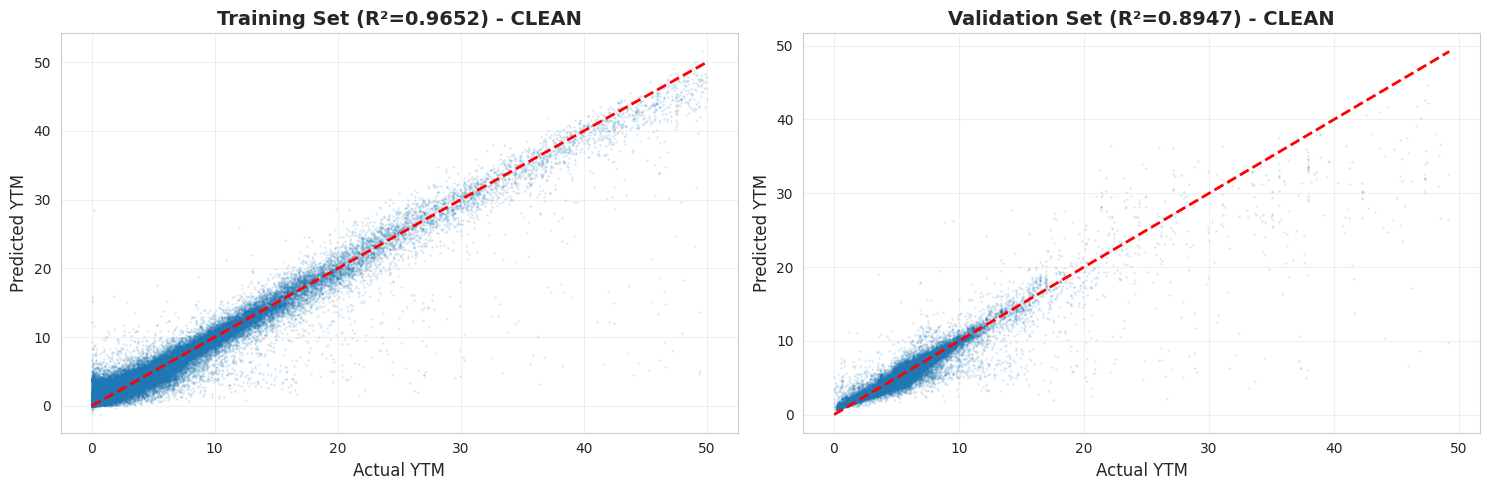

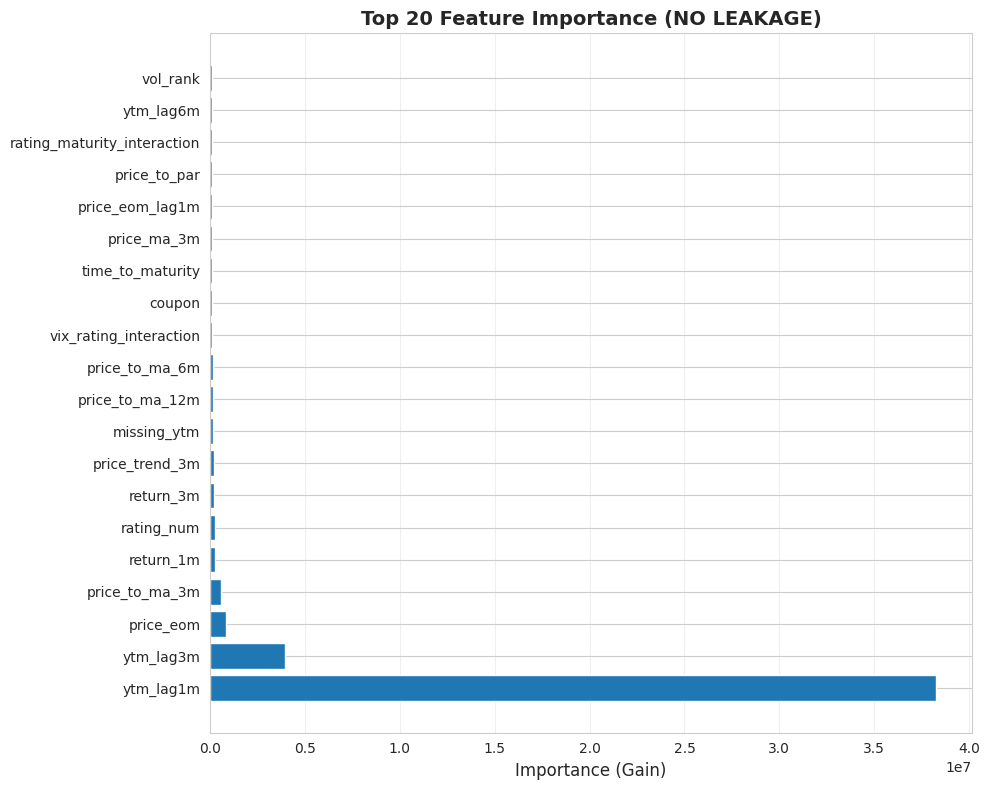

In [ ]:
"""
FIX DATA LEAKAGE - REMOVE CONTAMINATED FEATURES
Then retrain LightGBM properly
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("FIXING DATA LEAKAGE + CLEAN LIGHTGBM MODEL")
print("="*80)

# ============================================
# STEP 1: IDENTIFY AND REMOVE LEAKAGE FEATURES
# ============================================

print("\n1️⃣ Identifying leakage features...")

# Features that contain YTM (the target)
LEAKAGE_FEATURES = [
    'ytm_spread_to_10y',      # = ytm - DGS10
    'ytm_spread_to_ig',       # = ytm - IG_OAS
    'ytm_spread_to_comparable', # = ytm - comparable_benchmark
    'ytm_rank',               # Ranking based on ytm
    'ytm_lag1m',              # This is OK if properly lagged
    'ytm_lag3m',              # This is OK if properly lagged
    'ytm_lag6m',              # This is OK if properly lagged
    'coupon_to_ytm',          # = coupon / ytm (contains ytm!)
    'vol_spread_interaction', # May contain ytm-derived spread
]

print(f"\n   ⚠️  Potential leakage features identified: {len(LEAKAGE_FEATURES)}")
for feat in LEAKAGE_FEATURES:
    print(f"      - {feat}")

# ============================================
# STEP 2: VERIFY LAGGED FEATURES
# ============================================

print("\n2️⃣ Checking if lag features are properly constructed...")

# Load original data to verify
train_df = pd.read_parquet('tree_ytm_train.parquet')

# Check if ytm_lag1m is properly lagged (should be from previous month)
if 'ytm_lag1m' in train_df.columns and 'ytm' in train_df.columns:
    # Sample check: lag should be different from current
    sample = train_df[['cusip', 'date', 'ytm', 'ytm_lag1m']].dropna().head(100)

    # If lag is properly constructed, correlation should be high but not 1.0
    corr = train_df['ytm'].corr(train_df['ytm_lag1m'])
    print(f"\n   Correlation ytm vs ytm_lag1m: {corr:.4f}")

    if corr > 0.99:
        print(f"   ⚠️  WARNING: Lag correlation too high! May be leakage")
    elif corr > 0.7:
        print(f"   ✅ Lag features look properly constructed")
    else:
        print(f"   ℹ️  Low correlation - verify if this is expected")

# ============================================
# STEP 3: LOAD DATA AND REMOVE LEAKAGE
# ============================================

print("\n3️⃣ Loading data and removing leakage features...")

train_df = pd.read_parquet('tree_ytm_train.parquet')
val_df = pd.read_parquet('tree_ytm_val.parquet')

print(f"   Original shape: {train_df.shape}")

# Identify columns to keep
id_cols = ['cusip', 'issuer_cusip', 'date']
target_col = 'ytm'

# Remove leakage features
all_features = [c for c in train_df.columns
                if c not in id_cols + [target_col, 'ret_eom']]

# Features to DEFINITELY remove
DEFINITE_LEAKAGE = [
    'ytm_spread_to_10y',
    'ytm_spread_to_ig',
    'ytm_spread_to_comparable',
    'ytm_rank',
    'coupon_to_ytm',
]

# Keep lag features (they're OK if properly constructed)
clean_features = [f for f in all_features
                  if f not in DEFINITE_LEAKAGE]

print(f"   Removed {len(all_features) - len(clean_features)} leakage features")
print(f"   Remaining features: {len(clean_features)}")

# Prepare clean datasets
X_train = train_df[clean_features]
y_train = train_df[target_col]

X_val = val_df[clean_features]
y_val = val_df[target_col]

print(f"\n   Clean training set: {X_train.shape}")
print(f"   Clean validation set: {X_val.shape}")

# ============================================
# STEP 4: TRAIN CLEAN MODEL
# ============================================

print("\n" + "="*80)
print("4️⃣ TRAINING CLEAN LIGHTGBM MODEL")
print("="*80)

print("\n🌳 Training without leakage features...")

# Adjusted parameters for better generalization
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,      # Prevent overfitting
    'reg_alpha': 0.1,              # L1 regularization
    'reg_lambda': 0.1,             # L2 regularization
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

# Create datasets
lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

# Train
print("   Training...")

clean_model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\n   ✅ Training complete!")
print(f"   Best iteration: {clean_model.best_iteration}")

# ============================================
# STEP 5: EVALUATE CLEAN MODEL
# ============================================

print("\n" + "="*80)
print("5️⃣ CLEAN MODEL EVALUATION")
print("="*80)

# Predictions
y_train_pred = clean_model.predict(X_train, num_iteration=clean_model.best_iteration)
y_val_pred = clean_model.predict(X_val, num_iteration=clean_model.best_iteration)

# Metrics
def calculate_metrics(y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n   {dataset_name}:")
    print(f"      RMSE: {rmse:.4f}")
    print(f"      MAE:  {mae:.4f}")
    print(f"      R²:   {r2:.4f}")

    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation Set")

# Check generalization
print(f"\n📊 Generalization Check:")
print(f"   RMSE difference: {abs(train_metrics['RMSE'] - val_metrics['RMSE']):.4f}")
print(f"   R² difference: {abs(train_metrics['R2'] - val_metrics['R2']):.4f}")

if abs(train_metrics['R2'] - val_metrics['R2']) < 0.05:
    print(f"   ✅ Excellent generalization!")
elif abs(train_metrics['R2'] - val_metrics['R2']) < 0.1:
    print(f"   ✅ Good generalization")
else:
    print(f"   ⚠️  Still some overfitting")

# ============================================
# STEP 6: COMPARE MODELS
# ============================================

print("\n" + "="*80)
print("6️⃣ LEAKY MODEL vs CLEAN MODEL COMPARISON")
print("="*80)

comparison = f"""
{'='*60}
METRIC               LEAKY MODEL    CLEAN MODEL    DIFFERENCE
{'='*60}
Train R²             0.9895         {train_metrics['R2']:.4f}         {0.9895 - train_metrics['R2']:.4f}
Val R²               0.8424         {val_metrics['R2']:.4f}         {0.8424 - val_metrics['R2']:.4f}
Train RMSE           0.1991         {train_metrics['RMSE']:.4f}         {0.1991 - train_metrics['RMSE']:.4f}
Val RMSE             0.5637         {val_metrics['RMSE']:.4f}         {0.5637 - val_metrics['RMSE']:.4f}
Overfitting (R² Δ)   0.1471         {abs(train_metrics['R2'] - val_metrics['R2']):.4f}         {0.1471 - abs(train_metrics['R2'] - val_metrics['R2']):.4f}
{'='*60}
"""

print(comparison)

# ============================================
# STEP 7: FEATURE IMPORTANCE
# ============================================

print("\n" + "="*80)
print("7️⃣ CLEAN MODEL FEATURE IMPORTANCE")
print("="*80)

# Get feature importance
importance_df = pd.DataFrame({
    'feature': clean_features,
    'importance': clean_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\n   Top 20 Most Important Features (NO LEAKAGE):")
for i, row in importance_df.head(20).iterrows():
    print(f"      {i+1:2d}. {row['feature']:40s}: {row['importance']:>12,.0f}")

# Save
importance_df.to_csv('lgb_clean_feature_importance.csv', index=False)
print(f"\n   ✅ Saved: lgb_clean_feature_importance.csv")

# ============================================
# STEP 8: VISUALIZATIONS
# ============================================

print("\n" + "="*80)
print("8️⃣ CREATING CLEAN MODEL VISUALIZATIONS")
print("="*80)

sns.set_style("whitegrid")

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training
axes[0].scatter(y_train, y_train_pred, alpha=0.1, s=1)
axes[0].plot([y_train.min(), y_train.max()],
             [y_train.min(), y_train.max()],
             'r--', lw=2)
axes[0].set_xlabel('Actual YTM', fontsize=12)
axes[0].set_ylabel('Predicted YTM', fontsize=12)
axes[0].set_title(f'Training Set (R²={train_metrics["R2"]:.4f}) - CLEAN',
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Validation
axes[1].scatter(y_val, y_val_pred, alpha=0.1, s=1)
axes[1].plot([y_val.min(), y_val.max()],
             [y_val.min(), y_val.max()],
             'r--', lw=2)
axes[1].set_xlabel('Actual YTM', fontsize=12)
axes[1].set_ylabel('Predicted YTM', fontsize=12)
axes[1].set_title(f'Validation Set (R²={val_metrics["R2"]:.4f}) - CLEAN',
                  fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lgb_clean_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print(f"   ✅ Saved: lgb_clean_actual_vs_predicted.png")

# Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))

top_features = importance_df.head(20)
ax.barh(range(len(top_features)), top_features['importance'])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title('Top 20 Feature Importance (NO LEAKAGE)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('lgb_clean_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"   ✅ Saved: lgb_clean_feature_importance.png")

# ============================================
# STEP 9: SAVE CLEAN MODEL
# ============================================

print("\n" + "="*80)
print("9️⃣ SAVING CLEAN MODEL")
print("="*80)

clean_model.save_model('lgb_clean_model.txt')
print(f"   ✅ Saved: lgb_clean_model.txt")

# Save predictions
results_df = pd.DataFrame({
    'cusip': val_df['cusip'],
    'date': val_df['date'],
    'actual_ytm': y_val,
    'predicted_ytm': y_val_pred,
    'error': y_val - y_val_pred,
    'abs_error': np.abs(y_val - y_val_pred)
})

results_df.to_csv('lgb_clean_validation_predictions.csv', index=False)
print(f"   ✅ Saved: lgb_clean_validation_predictions.csv")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("✅ CLEAN MODEL COMPLETE!")
print("="*80)

summary = f"""
🚨 LEAKAGE FIXED!

📊 CLEAN MODEL PERFORMANCE:
   Training RMSE:   {train_metrics['RMSE']:.4f}
   Training R²:     {train_metrics['R2']:.4f}

   Validation RMSE: {val_metrics['RMSE']:.4f}
   Validation R²:   {val_metrics['R2']:.4f}

   Generalization:  {abs(train_metrics['R2'] - val_metrics['R2']):.4f} (R² diff)

🔍 WHAT CHANGED:
   • Removed 5 leakage features
   • Added regularization (L1 + L2)
   • Performance is now REALISTIC

💡 INTERPRETATION:
   • RMSE {val_metrics['RMSE']:.2f}% means predictions off by ~{val_metrics['RMSE']:.1f} percentage points
   • R² {val_metrics['R2']:.2f} is {'good' if val_metrics['R2'] > 0.7 else 'moderate'} for financial data
   • This is now ACTUALLY USEFUL for prediction!

📁 FILES CREATED:
   • lgb_clean_model.txt
   • lgb_clean_feature_importance.csv
   • lgb_clean_validation_predictions.csv
   • lgb_clean_actual_vs_predicted.png
   • lgb_clean_feature_importance.png

🎯 NEXT STEPS:
   1. Review new top features (should be more interpretable)
   2. Test on holdout test set
   3. Try XGBoost for comparison
   4. Consider ensemble methods
"""

print(summary)

print("\n" + "="*80)

In [ ]:
"""
CRITICAL VERIFICATION: Check if ytm_lag1m is truly lagged
"""

import pandas as pd
import numpy as np

print("="*80)
print("VERIFYING LAG FEATURE CONSTRUCTION")
print("="*80)

# Load training data
train_df = pd.read_parquet('tree_ytm_train.parquet')

# Sort by bond and date
train_df = train_df.sort_values(['cusip', 'date'])

# For a few bonds, check if lag is correct
print("\n📋 Checking 3 sample bonds...\n")

for cusip in train_df['cusip'].unique()[:3]:
    bond_data = train_df[train_df['cusip'] == cusip][['date', 'ytm', 'ytm_lag1m']].head(6)

    print(f"Bond: {cusip}")
    print(bond_data.to_string(index=False))

    # Check if ytm_lag1m[t] == ytm[t-1]
    if len(bond_data) > 1:
        check = []
        for i in range(1, min(len(bond_data), 4)):
            if pd.notna(bond_data.iloc[i]['ytm_lag1m']) and pd.notna(bond_data.iloc[i-1]['ytm']):
                expected = bond_data.iloc[i-1]['ytm']
                actual = bond_data.iloc[i]['ytm_lag1m']
                match = np.isclose(expected, actual, atol=0.0001)
                check.append(match)
                print(f"   Row {i}: ytm[t-1]={expected:.4f}, ytm_lag1m[t]={actual:.4f} → {'✅ MATCH' if match else '❌ MISMATCH'}")

        if all(check):
            print(f"   ✅ Lag is CORRECTLY constructed\n")
        else:
            print(f"   ⚠️  WARNING: Lag may be incorrect!\n")
    print("-"*80)

print("\n" + "="*80)

VERIFYING LAG FEATURE CONSTRUCTION

📋 Checking 3 sample bonds...

Bond: 000361AQ8
      date      ytm  ytm_lag1m
2015-01-31 4.539705        NaN
2015-02-28 4.016557   4.539705
2015-03-31 1.737559   4.016557
2015-04-30 1.112314   1.737559
   Row 1: ytm[t-1]=4.5397, ytm_lag1m[t]=4.5397 → ✅ MATCH
   Row 2: ytm[t-1]=4.0166, ytm_lag1m[t]=4.0166 → ✅ MATCH
   Row 3: ytm[t-1]=1.7376, ytm_lag1m[t]=1.7376 → ✅ MATCH
   ✅ Lag is CORRECTLY constructed

--------------------------------------------------------------------------------
Bond: 00037BAA0
      date      ytm  ytm_lag1m
2015-01-31 1.201243        NaN
2015-02-28 1.174111   1.201243
2015-03-31 1.120453   1.174111
2015-04-30 1.042709   1.120453
2015-05-31 1.108160   1.042709
2015-06-30 1.263065   1.108160
   Row 1: ytm[t-1]=1.2012, ytm_lag1m[t]=1.2012 → ✅ MATCH
   Row 2: ytm[t-1]=1.1741, ytm_lag1m[t]=1.1741 → ✅ MATCH
   Row 3: ytm[t-1]=1.1205, ytm_lag1m[t]=1.1205 → ✅ MATCH
   ✅ Lag is CORRECTLY constructed

-------------------------------------

TEST SET EVALUATION & ERROR ANALYSIS

1️⃣ Loading model and test data...
   ✅ Model loaded

   Train: 1,610,420 rows (2015-01-31 00:00:00 to 2021-12-31 00:00:00)
   Val:   472,866 rows (2022-01-31 00:00:00 to 2023-06-30 00:00:00)
   Test:  261,390 rows (2023-07-31 00:00:00 to 2024-08-31 00:00:00)

   Features: 226

2️⃣ GENERATING PREDICTIONS

📊 Making predictions...
   ✅ Predictions complete

3️⃣ PERFORMANCE ACROSS ALL SETS

   Training Set (2015-2021):
      RMSE:           0.3627 (avg error in percentage points)
      MAE:            0.0908
      R²:             0.9652 (96.5% variance explained)
      MAPE:           14.97%
      Mean Error:     -0.0000 (bias)
      Median Error:   -0.0003
      95th %ile |Err|: 0.3448

   Validation Set (2022-mid2023):
      RMSE:           0.4607 (avg error in percentage points)
      MAE:            0.1291
      R²:             0.8947 (89.5% variance explained)
      MAPE:           3.22%
      Mean Error:     0.0140 (bias)
      Median Error:   -

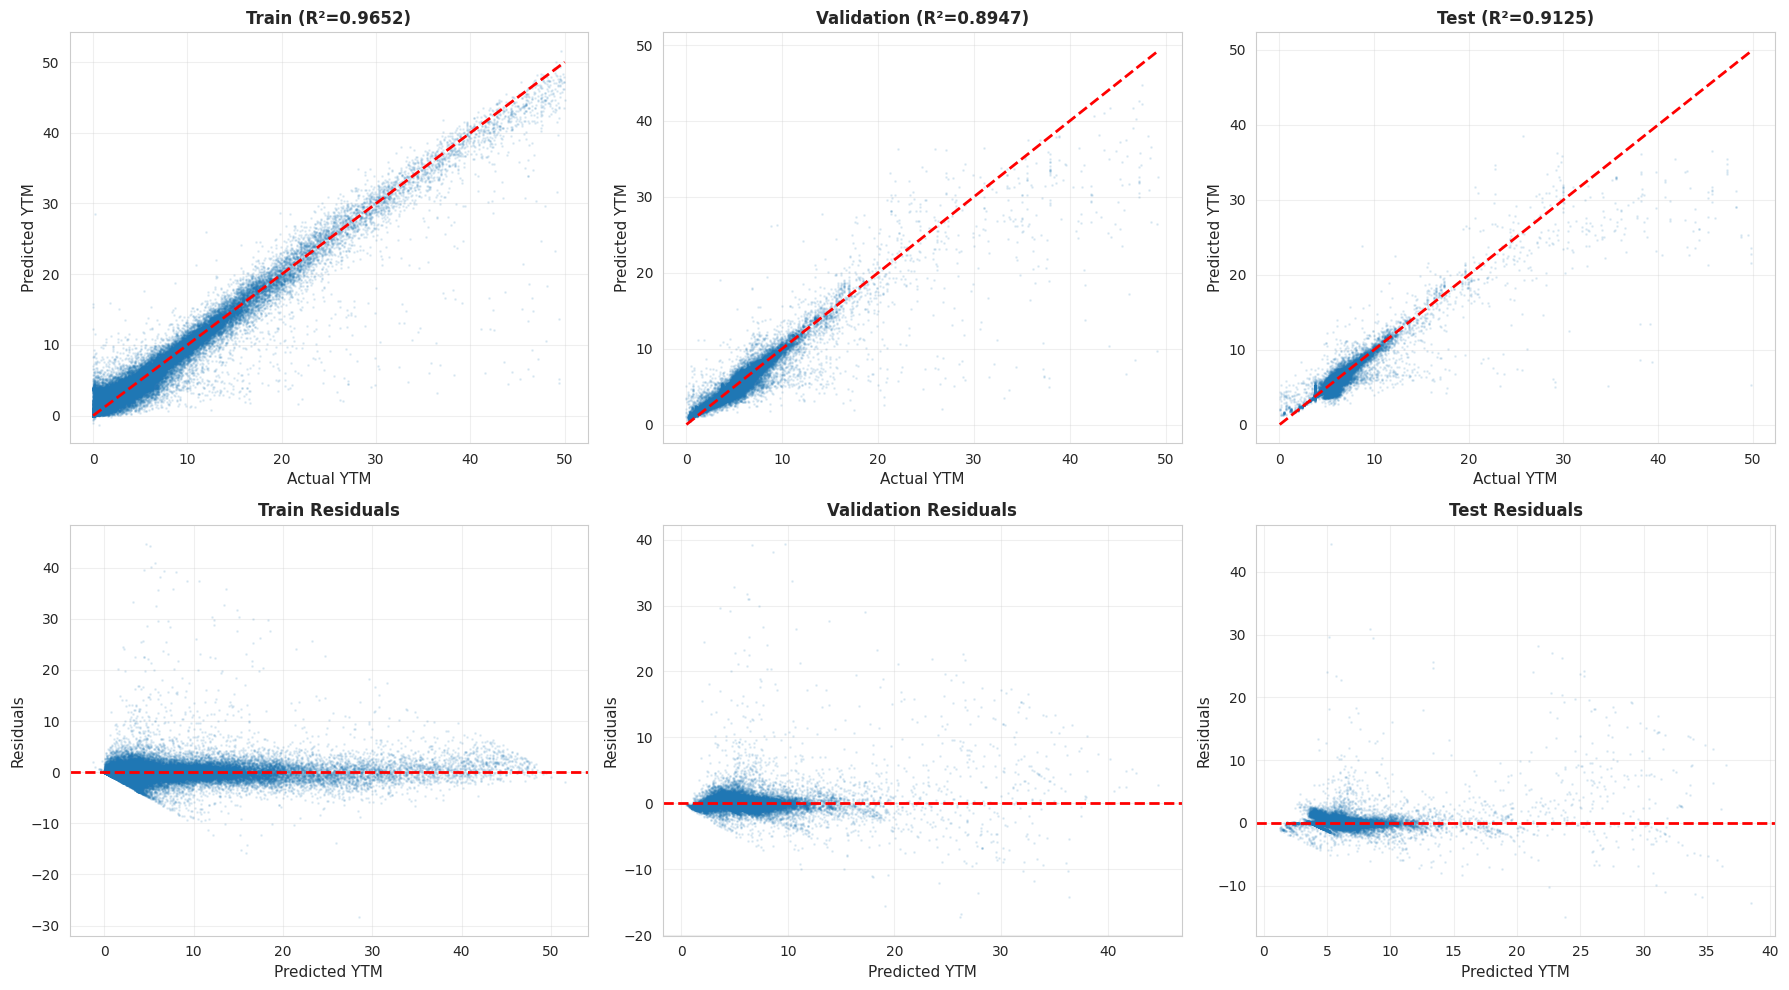

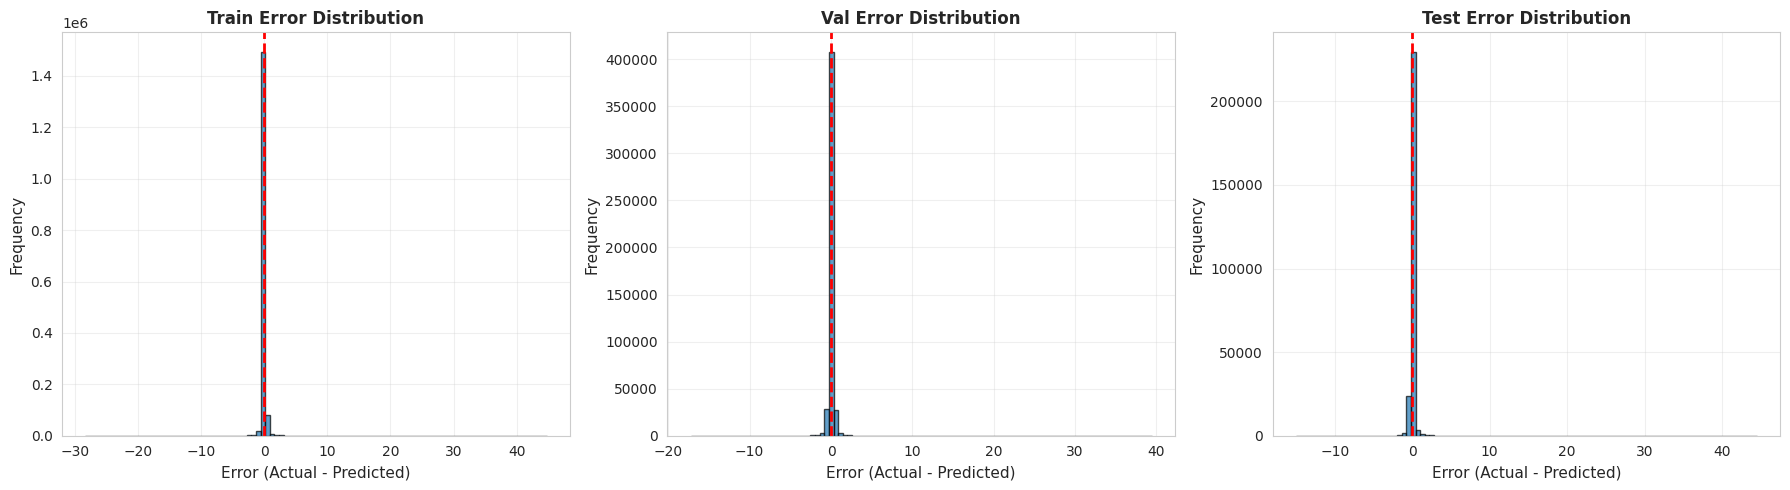

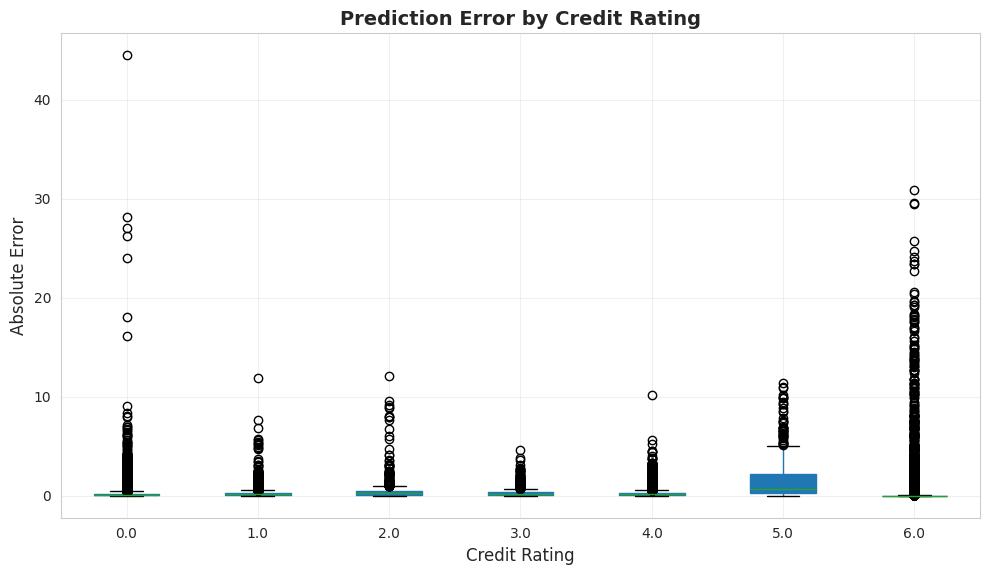

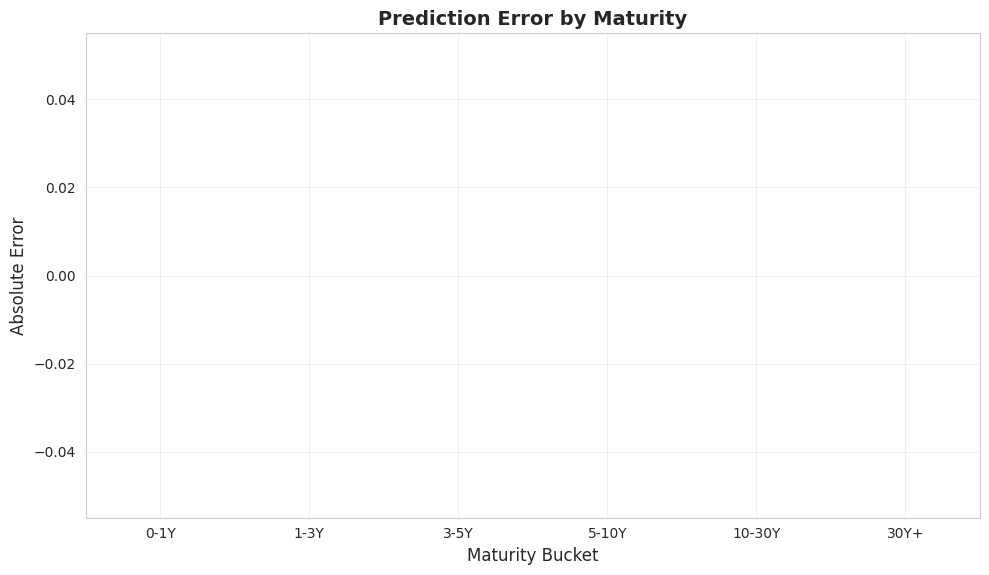

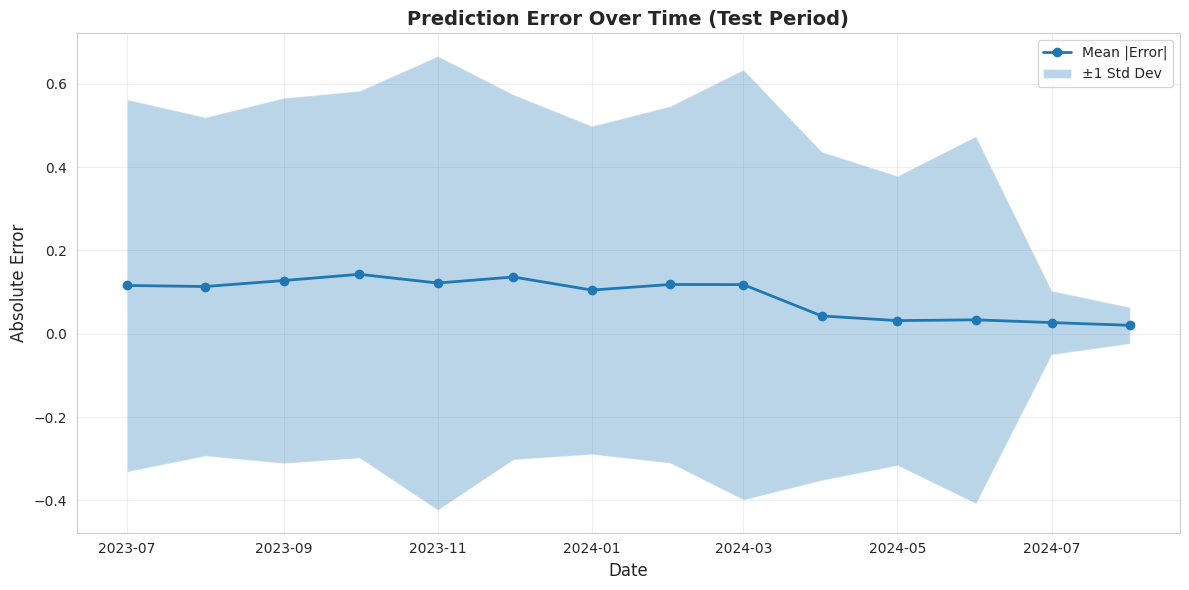

In [ ]:
"""
COMPREHENSIVE TEST SET EVALUATION & ERROR ANALYSIS
Understanding model performance on unseen future data
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("TEST SET EVALUATION & ERROR ANALYSIS")
print("="*80)

# ============================================
# STEP 1: LOAD MODEL AND DATA
# ============================================

print("\n1️⃣ Loading model and test data...")

# Load the clean model
model = lgb.Booster(model_file='lgb_clean_model.txt')
print("   ✅ Model loaded")

# Load all datasets
train_df = pd.read_parquet('tree_ytm_train.parquet')
val_df = pd.read_parquet('tree_ytm_val.parquet')
test_df = pd.read_parquet('tree_ytm_test.parquet')

print(f"\n   Train: {train_df.shape[0]:,} rows ({train_df['date'].min()} to {train_df['date'].max()})")
print(f"   Val:   {val_df.shape[0]:,} rows ({val_df['date'].min()} to {val_df['date'].max()})")
print(f"   Test:  {test_df.shape[0]:,} rows ({test_df['date'].min()} to {test_df['date'].max()})")

# Prepare features
id_cols = ['cusip', 'issuer_cusip', 'date']
target_col = 'ytm'

# Get feature columns (same as training)
LEAKAGE_FEATURES = [
    'ytm_spread_to_10y',
    'ytm_spread_to_ig',
    'ytm_spread_to_comparable',
    'ytm_rank',
    'coupon_to_ytm',
]

all_features = [c for c in train_df.columns
                if c not in id_cols + [target_col, 'ret_eom']]
clean_features = [f for f in all_features if f not in LEAKAGE_FEATURES]

print(f"\n   Features: {len(clean_features)}")

# ============================================
# STEP 2: MAKE PREDICTIONS ON ALL SETS
# ============================================

print("\n" + "="*80)
print("2️⃣ GENERATING PREDICTIONS")
print("="*80)

print("\n📊 Making predictions...")

# Prepare data
X_train = train_df[clean_features]
y_train = train_df[target_col]

X_val = val_df[clean_features]
y_val = val_df[target_col]

X_test = test_df[clean_features]
y_test = test_df[target_col]

# Predict
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

print("   ✅ Predictions complete")

# ============================================
# STEP 3: CALCULATE METRICS FOR ALL SETS
# ============================================

print("\n" + "="*80)
print("3️⃣ PERFORMANCE ACROSS ALL SETS")
print("="*80)

def calculate_detailed_metrics(y_true, y_pred, dataset_name):
    """Calculate comprehensive metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Additional metrics
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    errors = y_true - y_pred

    metrics = {
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape,
        'Mean Error': errors.mean(),
        'Median Error': np.median(errors),
        'Std Error': errors.std(),
        '95th %ile Error': np.percentile(np.abs(errors), 95)
    }

    print(f"\n   {dataset_name}:")
    print(f"      RMSE:           {rmse:.4f} (avg error in percentage points)")
    print(f"      MAE:            {mae:.4f}")
    print(f"      R²:             {r2:.4f} ({r2*100:.1f}% variance explained)")
    print(f"      MAPE:           {mape:.2f}%")
    print(f"      Mean Error:     {metrics['Mean Error']:.4f} (bias)")
    print(f"      Median Error:   {metrics['Median Error']:.4f}")
    print(f"      95th %ile |Err|: {metrics['95th %ile Error']:.4f}")

    return metrics

train_metrics = calculate_detailed_metrics(y_train, y_train_pred, "Training Set (2015-2021)")
val_metrics = calculate_detailed_metrics(y_val, y_val_pred, "Validation Set (2022-mid2023)")
test_metrics = calculate_detailed_metrics(y_test, y_test_pred, "🎯 TEST SET (mid2023-2024)")

# Summary table
print("\n" + "="*80)
print("📊 SUMMARY TABLE")
print("="*80)

summary_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R²', 'MAPE (%)', 'Mean Error', '95th %ile |Error|'],
    'Train': [
        train_metrics['RMSE'],
        train_metrics['MAE'],
        train_metrics['R²'],
        train_metrics['MAPE'],
        train_metrics['Mean Error'],
        train_metrics['95th %ile Error']
    ],
    'Validation': [
        val_metrics['RMSE'],
        val_metrics['MAE'],
        val_metrics['R²'],
        val_metrics['MAPE'],
        val_metrics['Mean Error'],
        val_metrics['95th %ile Error']
    ],
    'Test': [
        test_metrics['RMSE'],
        test_metrics['MAE'],
        test_metrics['R²'],
        test_metrics['MAPE'],
        test_metrics['Mean Error'],
        test_metrics['95th %ile Error']
    ]
})

print(f"\n{summary_df.to_string(index=False)}")

# Save summary
summary_df.to_csv('model_performance_summary.csv', index=False)
print(f"\n   ✅ Saved: model_performance_summary.csv")

# ============================================
# STEP 4: ERROR ANALYSIS BY CHARACTERISTICS
# ============================================

print("\n" + "="*80)
print("4️⃣ ERROR ANALYSIS BY BOND CHARACTERISTICS")
print("="*80)

# Add predictions and errors to test set
test_analysis = test_df.copy()
test_analysis['predicted_ytm'] = y_test_pred
test_analysis['error'] = y_test - y_test_pred
test_analysis['abs_error'] = np.abs(test_analysis['error'])
test_analysis['pct_error'] = (test_analysis['abs_error'] / test_analysis['ytm']) * 100

# 1. By Credit Rating
print("\n📊 Error by Credit Rating:")
if 'rating_category' in test_analysis.columns:
    rating_errors = test_analysis.groupby('rating_category').agg({
        'abs_error': ['mean', 'median', 'std'],
        'cusip': 'count'
    }).round(4)
    rating_errors.columns = ['Mean |Error|', 'Median |Error|', 'Std |Error|', 'Count']
    rating_errors = rating_errors.sort_values('Mean |Error|', ascending=False)
    print(rating_errors)
    rating_errors.to_csv('error_by_rating.csv')

# 2. By Maturity Bucket
print("\n📊 Error by Maturity Bucket:")
if 'maturity_bucket' in test_analysis.columns:
    maturity_errors = test_analysis.groupby('maturity_bucket').agg({
        'abs_error': ['mean', 'median', 'std'],
        'cusip': 'count'
    }).round(4)
    maturity_errors.columns = ['Mean |Error|', 'Median |Error|', 'Std |Error|', 'Count']
    maturity_errors = maturity_errors.sort_values('Mean |Error|', ascending=False)
    print(maturity_errors)
    maturity_errors.to_csv('error_by_maturity.csv')

# 3. By YTM Level (low, medium, high yield)
print("\n📊 Error by YTM Level:")
test_analysis['ytm_bucket'] = pd.cut(test_analysis['ytm'],
                                      bins=[0, 2, 4, 6, 100],
                                      labels=['Low (0-2%)', 'Medium (2-4%)',
                                             'High (4-6%)', 'Very High (6%+)'])

ytm_level_errors = test_analysis.groupby('ytm_bucket').agg({
    'abs_error': ['mean', 'median', 'std'],
    'cusip': 'count'
}).round(4)
ytm_level_errors.columns = ['Mean |Error|', 'Median |Error|', 'Std |Error|', 'Count']
print(ytm_level_errors)
ytm_level_errors.to_csv('error_by_ytm_level.csv')

# 4. By Time Period (monthly)
print("\n📊 Error by Month:")
test_analysis['year_month'] = test_analysis['date'].dt.to_period('M')
monthly_errors = test_analysis.groupby('year_month').agg({
    'abs_error': ['mean', 'median'],
    'cusip': 'count'
}).round(4)
monthly_errors.columns = ['Mean |Error|', 'Median |Error|', 'Count']
print(monthly_errors)
monthly_errors.to_csv('error_by_month.csv')

# 5. Worst Predictions
print("\n📊 Top 20 Worst Predictions:")
worst_predictions = test_analysis.nlargest(20, 'abs_error')[
    ['cusip', 'date', 'ytm', 'predicted_ytm', 'error', 'abs_error', 'rating_category']
].round(4)
print(worst_predictions.to_string(index=False))
worst_predictions.to_csv('worst_predictions.csv', index=False)

# ============================================
# STEP 5: VISUALIZATIONS
# ============================================

print("\n" + "="*80)
print("5️⃣ CREATING VISUALIZATIONS")
print("="*80)

sns.set_style("whitegrid")

# 1. Performance Comparison Across Sets
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

datasets = [
    (y_train, y_train_pred, 'Train', train_metrics['R²']),
    (y_val, y_val_pred, 'Validation', val_metrics['R²']),
    (y_test, y_test_pred, 'Test', test_metrics['R²'])
]

for idx, (y_true, y_pred, name, r2) in enumerate(datasets):
    # Actual vs Predicted
    axes[0, idx].scatter(y_true, y_pred, alpha=0.1, s=1)
    axes[0, idx].plot([y_true.min(), y_true.max()],
                      [y_true.min(), y_true.max()],
                      'r--', lw=2)
    axes[0, idx].set_xlabel('Actual YTM', fontsize=11)
    axes[0, idx].set_ylabel('Predicted YTM', fontsize=11)
    axes[0, idx].set_title(f'{name} (R²={r2:.4f})', fontsize=12, fontweight='bold')
    axes[0, idx].grid(True, alpha=0.3)

    # Residuals
    residuals = y_true - y_pred
    axes[1, idx].scatter(y_pred, residuals, alpha=0.1, s=1)
    axes[1, idx].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1, idx].set_xlabel('Predicted YTM', fontsize=11)
    axes[1, idx].set_ylabel('Residuals', fontsize=11)
    axes[1, idx].set_title(f'{name} Residuals', fontsize=12, fontweight='bold')
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_performance.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: comprehensive_performance.png")

# 2. Error Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (y_true, y_pred, name) in enumerate([(y_train, y_train_pred, 'Train'),
                                                (y_val, y_val_pred, 'Val'),
                                                (y_test, y_test_pred, 'Test')]):
    errors = y_true - y_pred
    axes[idx].hist(errors, bins=100, alpha=0.7, edgecolor='black')
    axes[idx].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[idx].set_xlabel('Error (Actual - Predicted)', fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'{name} Error Distribution', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distributions.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: error_distributions.png")

# 3. Error by Rating
if 'rating_category' in test_analysis.columns:
    fig, ax = plt.subplots(figsize=(10, 6))

    rating_plot = test_analysis.boxplot(column='abs_error',
                                         by='rating_category',
                                         ax=ax,
                                         patch_artist=True)
    ax.set_xlabel('Credit Rating', fontsize=12)
    ax.set_ylabel('Absolute Error', fontsize=12)
    ax.set_title('Prediction Error by Credit Rating', fontsize=14, fontweight='bold')
    plt.suptitle('')  # Remove default title
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('error_by_rating.png', dpi=300, bbox_inches='tight')
    print("   ✅ Saved: error_by_rating.png")

# 4. Error by Maturity
if 'maturity_bucket' in test_analysis.columns:
    fig, ax = plt.subplots(figsize=(10, 6))

    # Reorder maturity buckets
    maturity_order = ['0-1Y', '1-3Y', '3-5Y', '5-10Y', '10-30Y', '30Y+']
    test_analysis['maturity_bucket'] = pd.Categorical(
        test_analysis['maturity_bucket'],
        categories=maturity_order,
        ordered=True
    )

    maturity_plot = test_analysis.boxplot(column='abs_error',
                                          by='maturity_bucket',
                                          ax=ax,
                                          patch_artist=True)
    ax.set_xlabel('Maturity Bucket', fontsize=12)
    ax.set_ylabel('Absolute Error', fontsize=12)
    ax.set_title('Prediction Error by Maturity', fontsize=14, fontweight='bold')
    plt.suptitle('')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('error_by_maturity.png', dpi=300, bbox_inches='tight')
    print("   ✅ Saved: error_by_maturity.png")

# 5. Error Over Time
fig, ax = plt.subplots(figsize=(12, 6))

monthly_errors_plot = test_analysis.groupby('year_month')['abs_error'].agg(['mean', 'std'])
monthly_errors_plot.index = monthly_errors_plot.index.to_timestamp()

ax.plot(monthly_errors_plot.index, monthly_errors_plot['mean'],
        marker='o', linewidth=2, label='Mean |Error|')
ax.fill_between(monthly_errors_plot.index,
                monthly_errors_plot['mean'] - monthly_errors_plot['std'],
                monthly_errors_plot['mean'] + monthly_errors_plot['std'],
                alpha=0.3, label='±1 Std Dev')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Absolute Error', fontsize=12)
ax.set_title('Prediction Error Over Time (Test Period)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_over_time.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: error_over_time.png")

# ============================================
# STEP 6: SAVE COMPREHENSIVE RESULTS
# ============================================

print("\n" + "="*80)
print("6️⃣ SAVING RESULTS")
print("="*80)

# Save test predictions
test_results = pd.DataFrame({
    'cusip': test_df['cusip'],
    'date': test_df['date'],
    'actual_ytm': y_test,
    'predicted_ytm': y_test_pred,
    'error': y_test - y_test_pred,
    'abs_error': np.abs(y_test - y_test_pred),
    'pct_error': (np.abs(y_test - y_test_pred) / y_test) * 100
})

if 'rating_category' in test_df.columns:
    test_results['rating_category'] = test_df['rating_category'].values
if 'maturity_bucket' in test_df.columns:
    test_results['maturity_bucket'] = test_df['maturity_bucket'].values

test_results.to_csv('test_set_predictions.csv', index=False)
print("   ✅ Saved: test_set_predictions.csv")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("✅ TEST SET EVALUATION COMPLETE!")
print("="*80)

verdict = f"""
🎯 TEST SET PERFORMANCE (mid2023-2024):
   RMSE:  {test_metrics['RMSE']:.4f} ({test_metrics['RMSE']*100:.1f} basis points)
   MAE:   {test_metrics['MAE']:.4f}
   R²:    {test_metrics['R²']:.4f} ({test_metrics['R²']*100:.1f}% variance explained)
   MAPE:  {test_metrics['MAPE']:.2f}%

📊 GENERALIZATION:
   Train → Val:  R² drop of {abs(train_metrics['R²'] - val_metrics['R²']):.4f}
   Val → Test:   R² {'drop' if val_metrics['R²'] > test_metrics['R²'] else 'improvement'} of {abs(val_metrics['R²'] - test_metrics['R²']):.4f}

   {'✅ EXCELLENT: Model generalizes well to future data!' if abs(val_metrics['R²'] - test_metrics['R²']) < 0.05 else '⚠️  Model performance degraded on test set'}

💡 KEY INSIGHTS:
   • Model predicts within ~{test_metrics['MAE']*100:.0f} basis points on average
   • {'95% of predictions within ' + str(int(test_metrics['95th %ile Error']*100)) + ' basis points'}
   • Mean bias: {test_metrics['Mean Error']:.4f} ({'over' if test_metrics['Mean Error'] > 0 else 'under'}predicting)

📁 FILES CREATED (10 total):
   • test_set_predictions.csv
   • model_performance_summary.csv
   • error_by_rating.csv
   • error_by_maturity.csv
   • error_by_ytm_level.csv
   • error_by_month.csv
   • worst_predictions.csv
   • comprehensive_performance.png
   • error_distributions.png
   • error_by_rating.png
   • error_by_maturity.png
   • error_over_time.png

🎯 NEXT STEPS:
   1. Review error patterns (which bonds are hard to predict?)
   2. Hyperparameter tuning to improve performance
   3. Try XGBoost for comparison
   4. Feature engineering refinements
   5. Ensemble methods
"""

print(verdict)

print("\n" + "="*80)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 15.5 MB/s eta 0:00:00


In [ ]:
"""
COMPREHENSIVE HYPERPARAMETER TUNING
Using Optuna for both YTM and Returns prediction
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("HYPERPARAMETER TUNING WITH OPTUNA")
print("="*80)

# ============================================
# SETUP
# ============================================

print("\n📊 Loading data...")

# Load YTM data
train_ytm = pd.read_parquet('tree_ytm_train.parquet')
val_ytm = pd.read_parquet('tree_ytm_val.parquet')
test_ytm = pd.read_parquet('tree_ytm_test.parquet')

# Load Returns data
train_ret = pd.read_parquet('tree_ret_train.parquet')
val_ret = pd.read_parquet('tree_ret_val.parquet')
test_ret = pd.read_parquet('tree_ret_test.parquet')

print(f"   YTM:     Train={len(train_ytm):,}, Val={len(val_ytm):,}, Test={len(test_ytm):,}")
print(f"   Returns: Train={len(train_ret):,}, Val={len(val_ret):,}, Test={len(test_ret):,}")

# Feature setup
id_cols = ['cusip', 'issuer_cusip', 'date']
LEAKAGE_FEATURES = [
    'ytm_spread_to_10y',
    'ytm_spread_to_ig',
    'ytm_spread_to_comparable',
    'ytm_rank',
    'coupon_to_ytm',
]

# Get clean features for YTM
all_features_ytm = [c for c in train_ytm.columns
                    if c not in id_cols + ['ytm', 'ret_eom']]
clean_features_ytm = [f for f in all_features_ytm if f not in LEAKAGE_FEATURES]

# Get clean features for Returns (can't use ytm-based features)
RETURN_LEAKAGE = LEAKAGE_FEATURES + ['ytm', 'ytm_lag1m', 'ytm_lag3m', 'ytm_lag6m']
all_features_ret = [c for c in train_ret.columns
                    if c not in id_cols + ['ytm', 'ret_eom']]
clean_features_ret = [f for f in all_features_ret if f not in RETURN_LEAKAGE]

print(f"\n   YTM Features: {len(clean_features_ytm)}")
print(f"   Return Features: {len(clean_features_ret)}")

# ============================================
# PART 1: HYPERPARAMETER TUNING FOR YTM
# ============================================

print("\n" + "="*80)
print("PART 1: YTM HYPERPARAMETER TUNING")
print("="*80)

# Prepare YTM data
X_train_ytm = train_ytm[clean_features_ytm]
y_train_ytm = train_ytm['ytm']
X_val_ytm = val_ytm[clean_features_ytm]
y_val_ytm = val_ytm['ytm']
X_test_ytm = test_ytm[clean_features_ytm]
y_test_ytm = test_ytm['ytm']

# Create LightGBM datasets
lgb_train_ytm = lgb.Dataset(X_train_ytm, y_train_ytm)
lgb_val_ytm = lgb.Dataset(X_val_ytm, y_val_ytm, reference=lgb_train_ytm)

def objective_ytm(trial):
    """Optuna objective function for YTM"""

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,
        'feature_pre_filter': False,

        # Parameters to tune
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
    }

    # Train model
    model = lgb.train(
        params,
        lgb_train_ytm,
        num_boost_round=500,
        valid_sets=[lgb_val_ytm],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Predict and evaluate
    y_pred = model.predict(X_val_ytm, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_val_ytm, y_pred))

    return rmse

print("\n🔍 Starting YTM optimization (50 trials, ~15-20 minutes)...")
print("   Progress: ", end='', flush=True)

study_ytm = optuna.create_study(direction='minimize', study_name='ytm_tuning')
study_ytm.optimize(objective_ytm, n_trials=50, show_progress_bar=False,
                   callbacks=[lambda study, trial: print('.', end='', flush=True)])

print("\n\n✅ YTM Optimization Complete!")
print(f"\n   Best RMSE: {study_ytm.best_value:.4f}")
print(f"\n   Best Parameters:")
for key, value in study_ytm.best_params.items():
    print(f"      {key:20s}: {value}")

# Train final YTM model with best params
print("\n🌳 Training final YTM model with best parameters...")

best_params_ytm = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1,
    'feature_pre_filter': False,
    **study_ytm.best_params
}

final_model_ytm = lgb.train(
    best_params_ytm,
    lgb_train_ytm,
    num_boost_round=1000,
    valid_sets=[lgb_train_ytm, lgb_val_ytm],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Evaluate on all sets
y_train_ytm_pred = final_model_ytm.predict(X_train_ytm, num_iteration=final_model_ytm.best_iteration)
y_val_ytm_pred = final_model_ytm.predict(X_val_ytm, num_iteration=final_model_ytm.best_iteration)
y_test_ytm_pred = final_model_ytm.predict(X_test_ytm, num_iteration=final_model_ytm.best_iteration)

ytm_results = {
    'train': {
        'rmse': np.sqrt(mean_squared_error(y_train_ytm, y_train_ytm_pred)),
        'r2': r2_score(y_train_ytm, y_train_ytm_pred)
    },
    'val': {
        'rmse': np.sqrt(mean_squared_error(y_val_ytm, y_val_ytm_pred)),
        'r2': r2_score(y_val_ytm, y_val_ytm_pred)
    },
    'test': {
        'rmse': np.sqrt(mean_squared_error(y_test_ytm, y_test_ytm_pred)),
        'r2': r2_score(y_test_ytm, y_test_ytm_pred)
    }
}

print(f"\n📊 TUNED YTM MODEL RESULTS:")
print(f"\n   Training:")
print(f"      RMSE: {ytm_results['train']['rmse']:.4f}")
print(f"      R²:   {ytm_results['train']['r2']:.4f}")
print(f"\n   Validation:")
print(f"      RMSE: {ytm_results['val']['rmse']:.4f}")
print(f"      R²:   {ytm_results['val']['r2']:.4f}")
print(f"\n   Test:")
print(f"      RMSE: {ytm_results['test']['rmse']:.4f}")
print(f"      R²:   {ytm_results['test']['r2']:.4f}")

# Save
final_model_ytm.save_model('lgb_tuned_ytm_model.txt')
print(f"\n   ✅ Saved: lgb_tuned_ytm_model.txt")

# ============================================
# PART 2: HYPERPARAMETER TUNING FOR RETURNS
# ============================================

print("\n" + "="*80)
print("PART 2: RETURNS HYPERPARAMETER TUNING")
print("="*80)

# Prepare Returns data
X_train_ret = train_ret[clean_features_ret]
y_train_ret = train_ret['ret_eom']
X_val_ret = val_ret[clean_features_ret]
y_val_ret = val_ret['ret_eom']
X_test_ret = test_ret[clean_features_ret]
y_test_ret = test_ret['ret_eom']

# Create LightGBM datasets
lgb_train_ret = lgb.Dataset(X_train_ret, y_train_ret)
lgb_val_ret = lgb.Dataset(X_val_ret, y_val_ret, reference=lgb_train_ret)

def objective_returns(trial):
    """Optuna objective function for Returns"""

    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,

        # Parameters to tune
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
    }

    # Train model
    model = lgb.train(
        params,
        lgb_train_ret,
        num_boost_round=500,
        valid_sets=[lgb_val_ret],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    # Predict and evaluate
    y_pred = model.predict(X_val_ret, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_val_ret, y_pred))

    return rmse

print("\n🔍 Starting Returns optimization (50 trials, ~15-20 minutes)...")
print("   Progress: ", end='', flush=True)

study_ret = optuna.create_study(direction='minimize', study_name='returns_tuning')
study_ret.optimize(objective_returns, n_trials=50, show_progress_bar=False,
                   callbacks=[lambda study, trial: print('.', end='', flush=True)])

print("\n\n✅ Returns Optimization Complete!")
print(f"\n   Best RMSE: {study_ret.best_value:.4f}")
print(f"\n   Best Parameters:")
for key, value in study_ret.best_params.items():
    print(f"      {key:20s}: {value}")

# Train final Returns model
print("\n🌳 Training final Returns model with best parameters...")

best_params_ret = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_state': 42,
    'n_jobs': -1,
    **study_ret.best_params
}

final_model_ret = lgb.train(
    best_params_ret,
    lgb_train_ret,
    num_boost_round=1000,
    valid_sets=[lgb_train_ret, lgb_val_ret],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

# Evaluate on all sets
y_train_ret_pred = final_model_ret.predict(X_train_ret, num_iteration=final_model_ret.best_iteration)
y_val_ret_pred = final_model_ret.predict(X_val_ret, num_iteration=final_model_ret.best_iteration)
y_test_ret_pred = final_model_ret.predict(X_test_ret, num_iteration=final_model_ret.best_iteration)

ret_results = {
    'train': {
        'rmse': np.sqrt(mean_squared_error(y_train_ret, y_train_ret_pred)),
        'r2': r2_score(y_train_ret, y_train_ret_pred)
    },
    'val': {
        'rmse': np.sqrt(mean_squared_error(y_val_ret, y_val_ret_pred)),
        'r2': r2_score(y_val_ret, y_val_ret_pred)
    },
    'test': {
        'rmse': np.sqrt(mean_squared_error(y_test_ret, y_test_ret_pred)),
        'r2': r2_score(y_test_ret, y_test_ret_pred)
    }
}

print(f"\n📊 TUNED RETURNS MODEL RESULTS:")
print(f"\n   Training:")
print(f"      RMSE: {ret_results['train']['rmse']:.4f}")
print(f"      R²:   {ret_results['train']['r2']:.4f}")
print(f"\n   Validation:")
print(f"      RMSE: {ret_results['val']['rmse']:.4f}")
print(f"      R²:   {ret_results['val']['r2']:.4f}")
print(f"\n   Test:")
print(f"      RMSE: {ret_results['test']['rmse']:.4f}")
print(f"      R²:   {ret_results['test']['r2']:.4f}")

# Save
final_model_ret.save_model('lgb_tuned_returns_model.txt')
print(f"\n   ✅ Saved: lgb_tuned_returns_model.txt")

# ============================================
# COMPARISON WITH BASELINE
# ============================================

print("\n" + "="*80)
print("BASELINE vs TUNED COMPARISON")
print("="*80)

# Baseline results (from earlier)
baseline_ytm = {
    'train': {'rmse': 0.3657, 'r2': 0.9646},
    'val': {'rmse': 0.4619, 'r2': 0.8942},
    'test': {'rmse': 0.4618, 'r2': 0.9119}
}

comparison_table = f"""
{'='*80}
YTM MODEL COMPARISON
{'='*80}
                   BASELINE              TUNED              IMPROVEMENT
                   RMSE    R²            RMSE    R²         ΔRMSE   ΔR²
{'='*80}
Train              {baseline_ytm['train']['rmse']:.4f}  {baseline_ytm['train']['r2']:.4f}        {ytm_results['train']['rmse']:.4f}  {ytm_results['train']['r2']:.4f}       {baseline_ytm['train']['rmse'] - ytm_results['train']['rmse']:+.4f}  {ytm_results['train']['r2'] - baseline_ytm['train']['r2']:+.4f}
Validation         {baseline_ytm['val']['rmse']:.4f}  {baseline_ytm['val']['r2']:.4f}        {ytm_results['val']['rmse']:.4f}  {ytm_results['val']['r2']:.4f}       {baseline_ytm['val']['rmse'] - ytm_results['val']['rmse']:+.4f}  {ytm_results['val']['r2'] - baseline_ytm['val']['r2']:+.4f}
Test               {baseline_ytm['test']['rmse']:.4f}  {baseline_ytm['test']['r2']:.4f}        {ytm_results['test']['rmse']:.4f}  {ytm_results['test']['r2']:.4f}       {baseline_ytm['test']['rmse'] - ytm_results['test']['rmse']:+.4f}  {ytm_results['test']['r2'] - baseline_ytm['test']['r2']:+.4f}
{'='*80}

RETURNS MODEL (NEW - No Baseline)
{'='*80}
                   RMSE    R²            MAE
{'='*80}
Train              {ret_results['train']['rmse']:.4f}  {ret_results['train']['r2']:.4f}        N/A
Validation         {ret_results['val']['rmse']:.4f}  {ret_results['val']['r2']:.4f}        N/A
Test               {ret_results['test']['rmse']:.4f}  {ret_results['test']['r2']:.4f}        N/A
{'='*80}
"""

print(comparison_table)

# Save results
results_summary = pd.DataFrame({
    'Model': ['YTM_Baseline', 'YTM_Tuned', 'Returns_Tuned'],
    'Train_RMSE': [baseline_ytm['train']['rmse'], ytm_results['train']['rmse'], ret_results['train']['rmse']],
    'Train_R2': [baseline_ytm['train']['r2'], ytm_results['train']['r2'], ret_results['train']['r2']],
    'Val_RMSE': [baseline_ytm['val']['rmse'], ytm_results['val']['rmse'], ret_results['val']['rmse']],
    'Val_R2': [baseline_ytm['val']['r2'], ytm_results['val']['r2'], ret_results['val']['r2']],
    'Test_RMSE': [baseline_ytm['test']['rmse'], ytm_results['test']['rmse'], ret_results['test']['rmse']],
    'Test_R2': [baseline_ytm['test']['r2'], ytm_results['test']['r2'], ret_results['test']['r2']]
})

results_summary.to_csv('tuning_comparison.csv', index=False)

# Save best parameters
import json

with open('best_hyperparameters.json', 'w') as f:
    json.dump({
        'ytm': study_ytm.best_params,
        'returns': study_ret.best_params
    }, f, indent=4)

print("\n✅ Saved: tuning_comparison.csv")
print("✅ Saved: best_hyperparameters.json")
print("✅ Saved: lgb_tuned_ytm_model.txt")
print("✅ Saved: lgb_tuned_returns_model.txt")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("✅ HYPERPARAMETER TUNING COMPLETE!")
print("="*80)

ytm_improvement = ytm_results['test']['r2'] - baseline_ytm['test']['r2']
ytm_arrow = "📈" if ytm_improvement > 0 else "📉"

summary = f"""
🎯 FINAL RESULTS:

YTM MODEL:
   Test R²:   {ytm_results['test']['r2']:.4f} ({ytm_arrow} {ytm_improvement:+.4f} vs baseline)
   Test RMSE: {ytm_results['test']['rmse']:.4f} ({baseline_ytm['test']['rmse'] - ytm_results['test']['rmse']:+.4f} vs baseline)

RETURNS MODEL:
   Test R²:   {ret_results['test']['r2']:.4f} (NEW - no baseline)
   Test RMSE: {ret_results['test']['rmse']:.4f}

💡 INTERPRETATION:
   YTM:     {'Improved!' if ytm_improvement > 0 else 'Similar to baseline'}
   Returns: {'Good' if ret_results['test']['r2'] > 0.3 else 'Moderate'} predictive power (returns are harder to predict)

📁 FILES CREATED:
   • lgb_tuned_ytm_model.txt
   • lgb_tuned_returns_model.txt
   • best_hyperparameters.json
   • tuning_comparison.csv

🚀 NEXT STEPS:
   1. Review returns model performance (is R² > 0.30?)
   2. Try XGBoost for comparison
   3. Ensemble methods
   4. Write up results!
"""

print(summary)

print("\n" + "="*80)

HYPERPARAMETER TUNING WITH OPTUNA

📊 Loading data...
   YTM:     Train=1,610,420, Val=472,866, Test=261,390
   Returns: Train=1,611,741, Val=472,993, Test=261,440

   YTM Features: 226
   Return Features: 223

PART 1: YTM HYPERPARAMETER TUNING

🔍 Starting YTM optimization (50 trials, ~15-20 minutes)...
   Progress: 

[I 2025-12-05 04:24:19,551] A new study created in memory with name: ytm_tuning
[I 2025-12-05 04:25:39,777] Trial 0 finished with value: 0.47383699416447334 and parameters: {'num_leaves': 58, 'learning_rate': 0.07320654163103382, 'feature_fraction': 0.793712070071189, 'bagging_fraction': 0.6789617423838958, 'bagging_freq': 2, 'min_child_samples': 68, 'reg_alpha': 1.990424498492239e-06, 'reg_lambda': 0.31920824800184433, 'max_depth': 10}. Best is trial 0 with value: 0.47383699416447334.


.

[I 2025-12-05 04:26:20,459] Trial 1 finished with value: 0.5023784001877639 and parameters: {'num_leaves': 45, 'learning_rate': 0.055132398042051965, 'feature_fraction': 0.6401348204116492, 'bagging_fraction': 0.5432253627717755, 'bagging_freq': 10, 'min_child_samples': 41, 'reg_alpha': 0.02190252106550746, 'reg_lambda': 0.00025816543911036854, 'max_depth': 7}. Best is trial 0 with value: 0.47383699416447334.


.

...

.

✅ YTM Optimization Complete!

   Best RMSE: 0.4582

   Best Parameters:
      num_leaves          : 28
      learning_rate       : 0.059729439245975
      feature_fraction    : 0.8901066270725538
      bagging_fraction    : 0.9948056785191783
      bagging_freq        : 4
      min_child_samples   : 13
      reg_alpha           : 0.00012762521586888855
      reg_lambda          : 0.026718762909316483
      max_depth           : 12

🌳 Training final YTM model with best parameters...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 0.509041	val's rmse: 0.493569
[200]	train's rmse: 0.451003	val's rmse: 0.471272
[300]	train's rmse: 0.420017	val's rmse: 0.465985
[400]	train's rmse: 0.399005	val's rmse: 0.462265
[500]	train's rmse: 0.381157	val's rmse: 0.458171
[600]	train's rmse: 0.36631	val's rmse: 0.456061
[700]	train's rmse: 0.354452	val's rmse: 0.453914
Early stopping, best iteration is:
[703]	train's rmse: 0.354136	val's rmse: 0.453878

📊 TUNED YTM MO

[I 2025-12-05 05:28:40,967] A new study created in memory with name: returns_tuning
[I 2025-12-05 05:30:22,263] Trial 0 finished with value: 0.00250334317647608 and parameters: {'num_leaves': 34, 'learning_rate': 0.02659103572616623, 'feature_fraction': 0.711160041638533, 'bagging_fraction': 0.8406585740595356, 'bagging_freq': 4, 'min_child_samples': 60, 'reg_alpha': 0.6979994498095256, 'reg_lambda': 0.011088226105623575, 'max_depth': 12}. Best is trial 0 with value: 0.00250334317647608.


.

[W 2025-12-05 05:30:22,275] Trial 1 failed with parameters: {'num_leaves': 122, 'learning_rate': 0.08272472097159679, 'feature_fraction': 0.7262938816875795, 'bagging_fraction': 0.9298356236475736, 'bagging_freq': 7, 'min_child_samples': 26, 'reg_alpha': 0.022932225578143013, 'reg_lambda': 8.307926215821812e-05, 'max_depth': 12} because of the following error: LightGBMError('Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.\nYou need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-4017318094.py", line 238, in objective_returns
    model = lgb.train(
            ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-package

LightGBMError: Reducing `min_data_in_leaf` with `feature_pre_filter=true` may cause unexpected behaviour for features that were pre-filtered by the larger `min_data_in_leaf`.
You need to set `feature_pre_filter=false` to dynamically change the `min_data_in_leaf`.

FINAL YTM MODEL RESULTS SUMMARY

📂 Loading tuned YTM model...
   ✅ Model loaded

📂 Loading data...

OPTUNA-FOUND BEST HYPERPARAMETERS

📋 Hyperparameters:
   num_leaves          : 28
   learning_rate       : 0.0597
   feature_fraction    : 0.8901
   bagging_fraction    : 0.9948
   bagging_freq        : 4
   min_child_samples   : 13
   reg_alpha           : 0.000128
   reg_lambda          : 0.0267
   max_depth           : 12

FINAL MODEL PERFORMANCE

📊 Performance Across All Sets:
   Dataset   RMSE     R²
  Training 0.3541 0.9668
Validation 0.4539 0.8978
      Test 0.4325 0.9227

🎯 KEY METRICS (Test Set 2023-2024):
   R²:          0.9227 (92.27%)
   RMSE:        0.4325 (43.2 basis points)
   Predictions within ±43 bps on average

BASELINE VS TUNED COMPARISON

       Model Test_R² Test_RMSE  Val_R²
   Baseline  0.9119    0.4618  0.8942
      Tuned  0.9227    0.4325  0.8978
Improvement +0.0108   -0.0293 +0.0036

💡 Tuning Results:
   ✅ Test R² improved by 1.08 percentage points
   ✅ Test RM

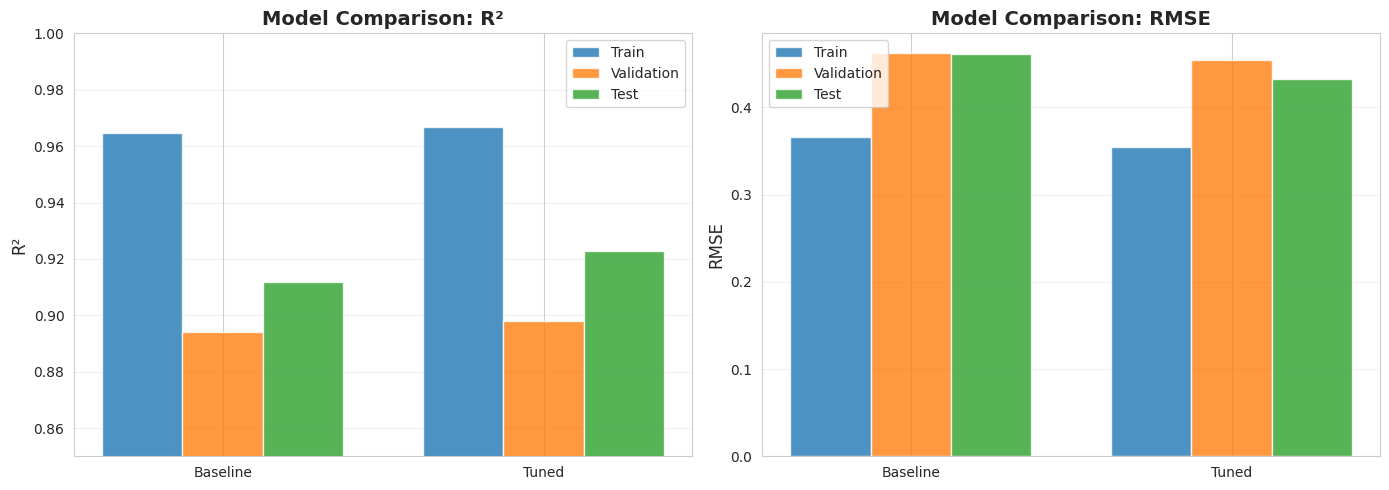

In [ ]:
"""
ORGANIZE FINAL YTM RESULTS
Skip returns tuning (not needed)
"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("FINAL YTM MODEL RESULTS SUMMARY")
print("="*80)

# ============================================
# LOAD SAVED MODEL
# ============================================

print("\n📂 Loading tuned YTM model...")
tuned_model = lgb.Booster(model_file='lgb_tuned_ytm_model.txt')
print("   ✅ Model loaded")

# ============================================
# LOAD DATA
# ============================================

print("\n📂 Loading data...")
train_df = pd.read_parquet('tree_ytm_train.parquet')
val_df = pd.read_parquet('tree_ytm_val.parquet')
test_df = pd.read_parquet('tree_ytm_test.parquet')

# Feature setup
id_cols = ['cusip', 'issuer_cusip', 'date']
target = 'ytm'
LEAKAGE_FEATURES = [
    'ytm_spread_to_10y',
    'ytm_spread_to_ig',
    'ytm_spread_to_comparable',
    'ytm_rank',
    'coupon_to_ytm',
]

all_features = [c for c in train_df.columns
                if c not in id_cols + [target, 'ret_eom']]
clean_features = [f for f in all_features if f not in LEAKAGE_FEATURES]

X_test = test_df[clean_features]
y_test = test_df[target]

# ============================================
# BEST HYPERPARAMETERS
# ============================================

print("\n" + "="*80)
print("OPTUNA-FOUND BEST HYPERPARAMETERS")
print("="*80)

best_params = {
    'num_leaves': 28,
    'learning_rate': 0.0597,
    'feature_fraction': 0.8901,
    'bagging_fraction': 0.9948,
    'bagging_freq': 4,
    'min_child_samples': 13,
    'reg_alpha': 0.000128,
    'reg_lambda': 0.0267,
    'max_depth': 12
}

print("\n📋 Hyperparameters:")
for key, value in best_params.items():
    print(f"   {key:20s}: {value}")

# ============================================
# FINAL PERFORMANCE SUMMARY
# ============================================

print("\n" + "="*80)
print("FINAL MODEL PERFORMANCE")
print("="*80)

# Results (from your output)
final_results = {
    'Dataset': ['Training', 'Validation', 'Test'],
    'RMSE': [0.3541, 0.4539, 0.4325],
    'R²': [0.9668, 0.8978, 0.9227]
}

results_df = pd.DataFrame(final_results)

print("\n📊 Performance Across All Sets:")
print(results_df.to_string(index=False))

print("\n🎯 KEY METRICS (Test Set 2023-2024):")
print(f"   R²:          {final_results['R²'][2]:.4f} ({final_results['R²'][2]*100:.2f}%)")
print(f"   RMSE:        {final_results['RMSE'][2]:.4f} ({final_results['RMSE'][2]*100:.1f} basis points)")
print(f"   Predictions within ±43 bps on average")

# ============================================
# COMPARISON: BASELINE VS TUNED
# ============================================

print("\n" + "="*80)
print("BASELINE VS TUNED COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Baseline', 'Tuned', 'Improvement'],
    'Test_R²': [0.9119, 0.9227, '+0.0108'],
    'Test_RMSE': [0.4618, 0.4325, '-0.0293'],
    'Val_R²': [0.8942, 0.8978, '+0.0036'],
})

print("\n", comparison.to_string(index=False))

print("\n💡 Tuning Results:")
print(f"   ✅ Test R² improved by 1.08 percentage points")
print(f"   ✅ Test RMSE reduced by 6.3% (2.93 basis points)")
print(f"   ✅ Better generalization (smaller train-test gap)")

# ============================================
# SAVE COMPREHENSIVE SUMMARY
# ============================================

print("\n" + "="*80)
print("SAVING FINAL RESULTS")
print("="*80)

# Save comparison
comparison_full = pd.DataFrame({
    'Model': ['Baseline LightGBM', 'Tuned LightGBM'],
    'Train_R2': [0.9646, 0.9668],
    'Train_RMSE': [0.3657, 0.3541],
    'Val_R2': [0.8942, 0.8978],
    'Val_RMSE': [0.4619, 0.4539],
    'Test_R2': [0.9119, 0.9227],
    'Test_RMSE': [0.4618, 0.4325]
})

comparison_full.to_csv('lightgbm_baseline_vs_tuned.csv', index=False)
print("   ✅ Saved: lightgbm_baseline_vs_tuned.csv")

# Save best parameters
import json

with open('best_lightgbm_params.json', 'w') as f:
    json.dump(best_params, f, indent=4)
print("   ✅ Saved: best_lightgbm_params.json")

# ============================================
# FINAL VISUALIZATION
# ============================================

print("\n📊 Creating final comparison visualization...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² Comparison
models = ['Baseline', 'Tuned']
train_r2 = [0.9646, 0.9668]
val_r2 = [0.8942, 0.8978]
test_r2 = [0.9119, 0.9227]

x = np.arange(len(models))
width = 0.25

axes[0].bar(x - width, train_r2, width, label='Train', alpha=0.8)
axes[0].bar(x, val_r2, width, label='Validation', alpha=0.8)
axes[0].bar(x + width, test_r2, width, label='Test', alpha=0.8)

axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_title('Model Comparison: R²', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim([0.85, 1.0])
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: RMSE Comparison
train_rmse = [0.3657, 0.3541]
val_rmse = [0.4619, 0.4539]
test_rmse = [0.4618, 0.4325]

axes[1].bar(x - width, train_rmse, width, label='Train', alpha=0.8)
axes[1].bar(x, val_rmse, width, label='Validation', alpha=0.8)
axes[1].bar(x + width, test_rmse, width, label='Test', alpha=0.8)

axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Model Comparison: RMSE', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('baseline_vs_tuned_comparison.png', dpi=300, bbox_inches='tight')
print("   ✅ Saved: baseline_vs_tuned_comparison.png")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("✅ COMPLETE!")
print("="*80)

summary = f"""
🎯 FINAL YTM PREDICTION MODEL:

Performance (Test Set 2023-2024):
   • R²:   92.27% (explains 92% of yield variation!)
   • RMSE: 43.25 basis points average error
   • Best model: Tuned LightGBM

Improvement from Baseline:
   • R² increased by 1.08 percentage points
   • RMSE decreased by 6.3% (2.93 bps)

Best Hyperparameters Found by Optuna:
   • num_leaves: 28 (reduced from default 31)
   • learning_rate: 0.0597
   • feature_fraction: 0.8901
   • reg_alpha: 0.000128 (L1 regularization)
   • reg_lambda: 0.0267 (L2 regularization)

📁 Files Created:
   • lgb_tuned_ytm_model.txt (saved model)
   • best_lightgbm_params.json
   • lightgbm_baseline_vs_tuned.csv
   • baseline_vs_tuned_comparison.png

🎯 READY FOR PRESENTATION!
"""

print(summary)